# ANC55 · P3HO₈ binding site

This notebook follows `ANC45_P3HO4_binding_modes.ipynb` in structure, helpers, plot style and methods, for **ANC55 + P3HO₈**. Here the PHA stays at **one binding site** for the whole 0–1000 ns, so there are no A/B states. Instead, the run is split into three sub-periods of the same site, chosen from steps in the minimum-distance trace: **P1 (0–230 ns) and P3 (720–1000 ns) are tighter** and **P2 (240–710 ns) is looser**. Figures 7–12 ask whether it really is one site (7), which residues hold the PHA (8), how strongly (9) and by how many contacts and hydrogen bonds (10), whether an ester carbonyl sits at the catalytic Ser138 (11), and which repeat units of the P3HO₈ chain bind (12).

**How to run:** select the **ipha_clean** kernel and choose Run All (about 4 minutes). Input files are only read. Every figure is saved as a 400 dpi PNG and CSVs in a new `analysis/binding_site_ANC55_P3HO8/<RUN_TAG>/` folder, and an existing folder is never overwritten.

**Figure 9** needs a GROMACS rerun (a few minutes on the CPU). With `RUN_RERUN = False` (the default) it loads the saved rerun results from `analysis/binding_site_ANC55_P3HO8/fig9_rerun_<sampling>/`. Set `RUN_RERUN = True` once to create them; an existing rerun folder is never overwritten.

In [1]:
from pathlib import Path
from datetime import datetime
import os, re, json, hashlib, tempfile, shutil, platform, warnings, subprocess
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.transforms import ScaledTranslation
from IPython.display import display, Markdown

# ===== EDIT HERE: the only configuration cell =====
BASE_DIR = Path('/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_new_Enzyme')
SYSTEM_FOLDER = 'ANC55_P3HO8_gromacs'
SOURCE_PREFIX = 'ANC55_P3HO8_new_enzyme_20261008_0_1000ns_v1'   # existing CSVs in analysis/
TPR_NAME = 'step7_production.tpr'
TRAJECTORY_NAME = 'processed_protein_centered.xtc'   # in analysis/; 0-1000 ns, 0.1 ns frames
EDR_NAME = 'production_combined_1us.edr'
RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M%S')   # or a fixed name; an existing folder is never overwritten
OUTPUT_ROOT = Path(os.environ.get('ANC55_BINDING_SITE_OUTPUT_ROOT',
                                  BASE_DIR / SYSTEM_FOLDER / 'analysis' / 'binding_site_ANC55_P3HO8'))
OUTPUT_DIR = OUTPUT_ROOT / RUN_TAG

CONTACT_CUTOFF_A = 3.5      # "in contact"
CLOSE_CUTOFF_A = 4.5        # "close site"
ACTIVE_SITE = {'SER138': ('SER', 138, ['OG']), 'ASP194': ('ASP', 194, ['OD1', 'OD2']), 'HSD226': ('HSD', 226, ['ND1', 'NE2'])}
PERIODS = {'P1': (0.0, 230.0), 'P2': (240.0, 710.0), 'P3': (720.0, 1000.0)}   # ns; sub-periods of ONE site
PERIOD_KIND = {'P1': 'tighter', 'P2': 'looser', 'P3': 'tighter'}            # never call these "states"
FULL_RANGE = (0.0, 1000.0)

SMOOTH_NS = 2.0                       # rolling mean for time series
HEATMAP_BIN_NS = 5.0                  # Figure 7 heatmap bins
PROFILE_BIN_NS = 50.0                 # Figure 7 leading-residue rule and similarity matrix
LEADING_PERCENT = 10.0                # Figure 7: residue shown if >= 10 % in any 50 ns bin
TOP_N_RESIDUES = 15                   # Figure 8
REFERENCE_OCCUPANCY = {('SER', 48): 68.2, ('SER', 138): 45.1, ('GLN', 93): 29.1}   # Figure 8 check, <= 3.5 A, 0-1000 ns
RUN_RERUN = False                     # Figure 9: True runs grompp + mdrun -rerun; False loads saved results
RERUN_STEP_NS = 1.0                   # Figure 9: frame spacing for the rerun
BLOCK_NS = 10.0                       # Figure 9: block length for the block SD
KEEP_RERUN_XTC = False                # Figure 9: False deletes the extracted rerun trajectory afterwards
GMX = shutil.which('gmx') or shutil.which('gmx_mpi')
GMX_THREADS = os.cpu_count()
HBOND_STEP_NS = 0.5                   # Figure 10: frame spacing for hydrogen bonds
HBOND_DA_CUTOFF_A, HBOND_ANGLE_DEG = 3.0, 150.0
HBOND_FOCUS_RESIDUE = ('SER', 48)     # Figure 10: does this H-bond explain the ~2.7 / ~3.2 A levels?
READY_CUTOFF_A = 3.5                  # Figure 11: d1 and d2 thresholds

COLOURS = {'all': '0.35', 'P1': 'tab:blue', 'P2': 'tab:orange', 'P3': 'tab:green'}
TRIAD_COLOUR = 'tab:red'
FIGSIZE, PNG_DPI = (8, 4.5), 400

plt.rcdefaults()
plt.rcParams.update({'figure.figsize': FIGSIZE, 'savefig.dpi': PNG_DPI,
                     'axes.spines.left': True, 'axes.spines.bottom': True,
                     'axes.spines.top': False, 'axes.spines.right': False})
SYSTEM_DIR = BASE_DIR / SYSTEM_FOLDER
GROUPS = ['all'] + list(PERIODS)
GROUP_LABEL = {'all': f'0–1000 ns'} | {p: f'{p} {PERIOD_KIND[p]} ({w[0]:g}–{w[1]:g} ns)' for p, w in PERIODS.items()}
GROUP_WINDOW = {'all': FULL_RANGE} | PERIODS
bounds = [w for w in PERIODS.values()]
if any(not (FULL_RANGE[0] <= a < b <= FULL_RANGE[1]) for a, b in bounds) or any(b0[1] > b1[0] for b0, b1 in zip(bounds[:-1], bounds[1:])):
    raise ValueError('PERIODS must be ordered, non-overlapping and inside 0-1000 ns')
RERUN_DIR = OUTPUT_ROOT / f'fig9_rerun_0-1000ns_every{RERUN_STEP_NS:g}ns'   # Figure 9 rerun files, shared by runs
print('Run tag:', RUN_TAG, '| output:', OUTPUT_DIR)
print('Figure 9:', 'run the rerun into' if RUN_RERUN else 'load saved rerun from', RERUN_DIR)
display(pd.DataFrame([{'period': p, 'start_ns': w[0], 'end_ns': w[1], 'label': PERIOD_KIND[p]} for p, w in PERIODS.items()]))

Run tag: 20261008_203845 | output: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_new_Enzyme/ANC55_P3HO8_gromacs/analysis/binding_site_ANC55_P3HO8/20261008_203845
Figure 9: load saved rerun from /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_new_Enzyme/ANC55_P3HO8_gromacs/analysis/binding_site_ANC55_P3HO8/fig9_rerun_0-1000ns_every1ns


,period,start_ns,end_ns,label
0,P1,0.0,230.0,tighter
1,P2,240.0,710.0,looser
2,P3,720.0,1000.0,tighter


### Helper functions

The loading, time-weighting and file-check helpers are copied unchanged from `ANC45_P3HO4_binding_modes.ipynb`, so occupancies are computed the same way. The save helpers refuse to replace an existing file.

In [2]:
def sha256(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for chunk in iter(lambda: f.read(1024*1024), b''): h.update(chunk)
    return h.hexdigest()

def file_record(path, digest=False):
    path = Path(path); stat = path.stat()
    result = {'path': str(path.resolve()), 'size': stat.st_size, 'mtime_ns': stat.st_mtime_ns}
    if digest: result['sha256'] = sha256(path)
    return result

def validate_times(times):
    t = np.asarray(times, float)
    if t.ndim != 1 or len(t) < 2 or not np.isfinite(t).all() or np.any(np.diff(t) <= 0):
        raise ValueError('Need finite strictly increasing times, with at least two samples')
    return t

def clip_series(times, values, start, end):
    t = validate_times(times); v = np.asarray(values, float)
    if v.shape[0] != len(t) or not np.isfinite(v).all() or not t[0] <= start < end <= t[-1]:
        raise ValueError('Invalid data or requested window outside real sampled coverage')
    inner = (t > start) & (t < end)
    matrix = v.reshape(len(t), -1)
    out = np.vstack(([np.interp(start, t, col) for col in matrix.T], matrix[inner],
                     [np.interp(end, t, col) for col in matrix.T]))
    return np.r_[start, t[inner], end], out.reshape((len(out),) + v.shape[1:])

def contact_duration(times, distances, cutoff):
    # Time at or below the cutoff, with linear interpolation of cutoff crossings.
    t = validate_times(times); d = np.asarray(distances, float)
    if d.shape[0] != len(t) or not np.isfinite(d).all() or np.any(d < 0) or not np.isfinite(cutoff) or cutoff <= 0:
        raise ValueError('Invalid distances or cutoff')
    left, right = d[:-1], d[1:]; il, ir = left <= cutoff, right <= cutoff
    fraction = (il & ir).astype(float); crossing = il != ir
    f = (cutoff - left[crossing]) / (right[crossing] - left[crossing])
    fraction[crossing] = np.where(il[crossing], f, 1 - f)
    dt = np.diff(t).reshape((-1,) + (1,) * (d.ndim - 1))
    return np.sum(dt * np.clip(fraction, 0, 1), axis=0)

def check_raw_provenance(paths, meta):
    for key in ('tpr', 'xtc'):
        if paths[key].resolve() != Path(meta['inputs'][key]).resolve(): raise ValueError('Source path changed')
        rec = file_record(paths[key])
        if [rec['size'], rec['mtime_ns']] != meta['input_size_mtime_ns'][key]:
            raise ValueError(f'{key}: source differs from saved provenance')

def check_distances(d, residues, global_data):
    cols = residues.distance_column.tolist()
    if d.columns.tolist() != ['frame', 'time_ns'] + cols or len(cols) != len(set(cols)) or residues.resindex.duplicated().any():
        raise ValueError('Residue identifiers do not match distance schema')
    validate_times(d.time_ns)
    if not np.isfinite(d[cols]).all().all() or (d[cols] < 0).any().any(): raise ValueError('Invalid distances')
    g = global_data.set_index('frame').loc[d.frame]
    if not np.allclose(g.time_ns, d.time_ns, atol=1e-8, rtol=0) or not np.allclose(g.enzyme_pha_min_distance_A, d[cols].min(axis=1), atol=2e-5, rtol=0):
        raise ValueError('All-residue minima do not reproduce global distances/frames')

def occupancy_percent(window, cutoff=CONTACT_CUTOFF_A):
    # Time-weighted % of the window that each residue spends within the cutoff of the PHA.
    start, end = window
    t, v = clip_series(T, DIST, start, end)
    return 100 * contact_duration(t, v, cutoff) / (end - start)

def in_window(times, window):
    return (np.asarray(times) >= window[0]) & (np.asarray(times) <= window[1])

def group_masks(times):
    return {g: in_window(times, GROUP_WINDOW[g]) for g in GROUPS}

def save_csv(table, name):
    path = OUTPUT_DIR / name
    if path.exists(): raise FileExistsError(f'Refusing to overwrite {path}')
    table.to_csv(path, index=False); SAVED.append(path)

def save_png(fig, name):
    path = OUTPUT_DIR / name
    if path.exists(): raise FileExistsError(f'Refusing to overwrite {path}')
    fig.savefig(path, dpi=PNG_DPI); SAVED.append(path)

def tidy(ax):
    ax.set_axisbelow(True); ax.grid(alpha=0.3)

def shade_periods(ax, label=False):
    for p, (start, end) in PERIODS.items():
        ax.axvspan(start, end, color=COLOURS[p], alpha=0.12, lw=0)
        if label:
            ax.text((start + end) / 2, 1.0, f'{p} {PERIOD_KIND[p]}', transform=ax.get_xaxis_transform(),
                    ha='center', va='bottom', fontsize=8, color=COLOURS[p], fontweight='bold')

def colour_triad_ticks(ticklabels):
    names = [f'{r}{i}' for r, i, _ in ACTIVE_SITE.values()]
    for tick in ticklabels:
        if any(tick.get_text() == n or tick.get_text().startswith(n + ' ') for n in names):
            tick.set_color(TRIAD_COLOUR); tick.set_fontweight('bold')

def group_bars(ax, categories, values, groups=GROUPS, horizontal=False, width=0.8, labels=True):
    # values: dict group -> array over categories
    n = len(groups); w = width / n; pos = np.arange(len(categories))
    for j, g in enumerate(groups):
        off = (j - (n - 1) / 2) * w
        if horizontal:
            ax.barh(pos + off, values[g], height=w, color=COLOURS[g], label=GROUP_LABEL[g] if labels else None)
        else:
            ax.bar(pos + off, values[g], width=w, color=COLOURS[g], label=GROUP_LABEL[g] if labels else None)
    return pos

# Analytic checks of the copied helpers: uneven intervals, exact cutoff.
assert np.isclose(contact_duration([0, 3, 10], np.array([2, 2, 5]), 3.5), 6.5)
assert contact_duration([0, 10], np.array([3.5, 3.5]), 3.5) == 10

### Load inputs and run the checks

This cell checks that the saved CSVs and the trajectory are the files that produced the earlier analysis (sizes, modification times and SHA-256 hashes), and that the saved contacts and occupancies are reproduced from the saved distances. It checks SER138, ASP194 and HSD226 and their atoms in the residue table and the TPR, lists the P3HO₈ carbonyl carbons and OH donors, and splits the chain into its 8 repeat units at the ester bonds. It stops with a message, before any figure is made, if anything differs.

In [3]:
import MDAnalysis as mda

prefix = SYSTEM_DIR / 'analysis' / SOURCE_PREFIX
PATHS = {'tpr': SYSTEM_DIR / TPR_NAME, 'xtc': SYSTEM_DIR / 'analysis' / TRAJECTORY_NAME, 'edr': SYSTEM_DIR / EDR_NAME,
         'global': Path(f'{prefix}_enzyme_pha_min_distance.csv'), 'summary': Path(f'{prefix}_summary.json'),
         'distances': Path(f'{prefix}_residue_pha_distances_A.csv'), 'residues': Path(f'{prefix}_residue_pha_residues.csv'),
         'metadata': Path(f'{prefix}_residue_pha_metadata.json'), 'contacts': Path(f'{prefix}_residue_pha_contacts_3p5A.csv'),
         'occupancy': Path(f'{prefix}_residue_pha_occupancy_3p5A.csv'), 'top10': Path(f'{prefix}_residue_pha_top10_overall_3p5A.csv')}
missing = [str(p) for p in PATHS.values() if not p.is_file()]
if missing:
    raise FileNotFoundError('Missing input files:\n' + '\n'.join(missing))

# 1. Inputs are the files that produced the earlier analysis.
summary_json = json.loads(PATHS['summary'].read_text()); metadata_json = json.loads(PATHS['metadata'].read_text())
check_raw_provenance(PATHS, summary_json); check_raw_provenance(PATHS, metadata_json)
for key, hashkey in [('distances', 'distance_csv_sha256'), ('residues', 'residue_csv_sha256'), ('global', 'figure3_sha256')]:
    if sha256(PATHS[key]) != metadata_json[hashkey]:
        raise ValueError(f'{PATHS[key].name} changed since the residue analysis was saved')
global_data = pd.read_csv(PATHS['global'], usecols=['frame', 'time_ns', 'enzyme_pha_min_distance_A'])
distances = pd.read_csv(PATHS['distances'])
residues = pd.read_csv(PATHS['residues'], keep_default_na=False)
check_distances(distances, residues.drop(columns='active_site'), global_data)

FRAMES = distances.frame.to_numpy()
T = distances.time_ns.to_numpy()
DIST = distances[residues.distance_column].to_numpy()          # frames x residues, Å
GMIN = global_data.set_index('frame').loc[FRAMES, 'enzyme_pha_min_distance_A'].to_numpy()
DT = float(np.median(np.diff(T)))
RES_LABELS = (residues.resname + residues.resid.astype(str)).to_numpy()
if not (np.array_equal(FRAMES, np.arange(FRAMES[0], FRAMES[0] + len(FRAMES))) and np.allclose(np.diff(T), DT, atol=1e-6)):
    raise ValueError('Expected contiguous frames with uniform spacing')
if not (T[0] <= FULL_RANGE[0] and T[-1] >= FULL_RANGE[1]):
    raise ValueError('Distances do not cover 0-1000 ns')

# 2. Saved contacts and occupancies are reproduced from the saved distances.
contacts_saved = pd.read_csv(PATHS['contacts'])
contact_cols = [c.removesuffix('_A') + '_contact' for c in residues.distance_column]
if contacts_saved.columns.tolist() != ['frame', 'time_ns'] + contact_cols or not np.array_equal(contacts_saved[contact_cols].to_numpy().astype(bool), DIST <= CONTACT_CUTOFF_A):
    raise ValueError('Saved 3.5 Å contacts do not match the saved distances')
OCC_ALL = occupancy_percent(FULL_RANGE)
occ_saved = pd.read_csv(PATHS['occupancy']).set_index('distance_column').loc[residues.distance_column, 'percent_within'].to_numpy()
if not np.allclose(OCC_ALL, occ_saved, atol=1e-6):
    raise ValueError('Saved 3.5 Å occupancies are not reproduced')
top10_saved = pd.read_csv(PATHS['top10']).sort_values('rank').resindex.tolist()
if top10_saved != residues.resindex.to_numpy()[np.argsort(-OCC_ALL, kind='stable')][:10].tolist():
    raise ValueError('Saved top-10 table does not match the recomputed occupancies')

# 3. Active site in the residue table, the saved summary and the TPR.
problems = []
for label, (resname, resid, names) in ACTIVE_SITE.items():
    hit = residues.loc[residues.resid == resid]
    if len(hit) != 1 or hit.resname.iloc[0] != resname:
        problems.append(f'residue table: expected {resname}{resid}, found {hit.resname.tolist()}')
saved_site = {(a['resname'], a['resid']): a['required_atoms'] for a in summary_json.get('active_site', [])}
if saved_site != {(r, i): sorted(n) for r, i, n in ACTIVE_SITE.values()} and saved_site != {(r, i): n for r, i, n in ACTIVE_SITE.values()}:
    problems.append(f'saved summary lists a different active site: {saved_site}')
SCRATCH = Path(tempfile.mkdtemp(prefix='anc55_binding_site_'))
(SCRATCH / 'trajectory.xtc').symlink_to(PATHS['xtc'])   # keeps MDAnalysis offset files out of the data folder
U = mda.Universe(str(PATHS['tpr']), str(SCRATCH / 'trajectory.xtc'))
ATOMS = {}
for label, (resname, resid, names) in ACTIVE_SITE.items():
    res = U.select_atoms(f'protein and resid {resid}').residues
    if len(res) != 1 or res.resnames[0] != resname:
        problems.append(f'TPR: expected {resname}{resid}, found {list(res.resnames)}'); continue
    for name in names:
        atom = res.atoms.select_atoms(f'name {name}')
        if len(atom) != 1: problems.append(f'TPR: {label} has no single atom {name}')
        ATOMS[f'{label}_{name}'] = atom

# 4. P3HO8: carbonyl carbons, OH donors and repeat units.
LIG = U.select_atoms('resname LIG')
CARBONYL_C = LIG.select_atoms('type CG2O2')
CARBONYL_KIND = {a.name: ('ester' if 'OG302' in a.bonded_atoms.types else 'acid end' if 'OG311' in a.bonded_atoms.types else '?')
                 for a in CARBONYL_C}
kinds = list(CARBONYL_KIND.values())
if len(CARBONYL_C) != 8 or kinds.count('ester') != 7 or kinds.count('acid end') != 1:
    problems.append(f'LIG carbonyl carbons (CG2O2): expected 8 = 7 ester + 1 acid end, found {CARBONYL_KIND}')
OH_GROUPS = [(a, b) for a in LIG if a.type == 'OG311' for b in a.bonded_atoms if b.element == 'H']
if len(OH_GROUPS) != 2:
    problems.append(f'LIG OH donors: expected 2, found {[(o.name, h.name) for o, h in OH_GROUPS]}')
# Units: cut each ester C(=O)-O bond; unit 1 holds the hydroxyl-end OH (on an sp3 carbon), then follow the chain.
ester_bonds = {frozenset((c.index, o.index)) for c in CARBONYL_C for o in c.bonded_atoms if o.type == 'OG302'}
neighbours = {a.index: [b.index for b in a.bonded_atoms if b.resname == 'LIG' and frozenset((a.index, b.index)) not in ester_bonds] for a in LIG}
component = {}
for start in LIG.indices:
    if start in component: continue
    stack = [start]; component[start] = start
    while stack:
        i = stack.pop()
        for j in neighbours[i]:
            if j not in component: component[j] = start; stack.append(j)
roots = {}
for i, root in component.items(): roots.setdefault(root, []).append(i)
hydroxyl_o = [o for o, h in OH_GROUPS if not any(b.type == 'CG2O2' for b in o.bonded_atoms)]
UNITS = []
if len(hydroxyl_o) == 1 and len(roots) == 8:
    current = component[hydroxyl_o[0].index]
    while current is not None and len(UNITS) < 8:
        UNITS.append(U.atoms[sorted(roots[current])])
        carbonyl = [a for a in UNITS[-1] if a.type == 'CG2O2']
        nxt = [component[o.index] for a in carbonyl for o in a.bonded_atoms if o.type == 'OG302']
        current = nxt[0] if nxt else None
if len(UNITS) != 8 or sum(len(u) for u in UNITS) != len(LIG):
    problems.append(f'LIG did not split into 8 linked repeat units from the hydroxyl end ({len(UNITS)} found)')
if problems:
    raise RuntimeError('Checks failed, so no figures were made:\n- ' + '\n- '.join(problems))
UNIT_TABLE = pd.DataFrame([{'unit': k + 1, 'atoms': len(u), 'heavy_atoms': int((u.masses > 3).sum()),
                            'carbonyl_C': ' '.join(a.name for a in u if a.type == 'CG2O2'),
                            'carbonyl_kind': ' '.join(CARBONYL_KIND[a.name] for a in u if a.type == 'CG2O2'),
                            'end_group': 'hydroxyl end (OH)' if k == 0 else 'acid end (COOH)' if k == 7 else ''}
                           for k, u in enumerate(UNITS)])
CARBONYL_UNIT = {a.name: k + 1 for k, u in enumerate(UNITS) for a in u if a.type == 'CG2O2'}
for i in (0, len(T) // 2, len(T) - 1):
    if not np.isclose(U.trajectory[int(FRAMES[i])].time / 1000, T[i], atol=1e-6):
        raise ValueError('Trajectory frame times do not match the CSV')

if OUTPUT_DIR.exists():
    raise FileExistsError(f'{OUTPUT_DIR} already exists; choose a new RUN_TAG')
OUTPUT_DIR.mkdir(parents=True)
SAVED = []
print(f'Checks passed: {len(residues)} residues, {len(T)} frames ({T[0]:g}-{T[-1]:g} ns, every {DT:g} ns); '
      'saved contacts, occupancies and top-10 table reproduced.')
print('Active site atoms:', ', '.join(ATOMS))
print('LIG carbonyl carbons (CG2O2):', ', '.join(f'{n} ({k}, unit {CARBONYL_UNIT[n]})' for n, k in CARBONYL_KIND.items()))
print('LIG OH donors:', ', '.join(f'{o.name}–{h.name} ({"acid end" if any(b.type == "CG2O2" for b in o.bonded_atoms) else "hydroxyl end"})' for o, h in OH_GROUPS))
display(UNIT_TABLE)
save_csv(UNIT_TABLE, 'lig_repeat_units.csv')

/opt/homebrew/Caskroom/miniconda/base/envs/ipha_clean/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Checks passed: 244 residues, 10001 frames (0-1000 ns, every 0.1 ns); saved contacts, occupancies and top-10 table reproduced.
Active site atoms: SER138_OG, ASP194_OD1, ASP194_OD2, HSD226_ND1, HSD226_NE2
LIG carbonyl carbons (CG2O2): C8 (ester, unit 1), C16 (ester, unit 2), C24 (ester, unit 3), C32 (ester, unit 4), C40 (ester, unit 5), C48 (ester, unit 6), C56 (ester, unit 7), C64 (acid end, unit 8)
LIG OH donors: O1–H1 (hydroxyl end), O17–H114 (acid end)


,unit,atoms,heavy_atoms,carbonyl_C,carbonyl_kind,end_group
0,1,25,10,C8,ester,hydroxyl end (OH)
1,2,24,10,C16,ester,
2,3,24,10,C24,ester,
3,4,24,10,C32,ester,
4,5,24,10,C40,ester,
5,6,24,10,C48,ester,
6,7,24,10,C56,ester,
7,8,26,11,C64,acid end,acid end (COOH)


### Figure 7 — One site over time

**Question:** does the PHA stay at one binding site for the whole run? **How to read it:** the top panel is the minimum enzyme–PHA distance (grey per frame, black 2 ns mean) with P1–P3 shaded. The middle panel shows, per 5 ns bin, how much of the time each leading residue (≥10 % in any 50 ns bin; active-site residues always shown, in red) is within 3.5 Å. The bottom panel compares the contact profiles of every pair of 50 ns bins: values near 1 mean the same residues hold the PHA, so a matrix that is high everywhere is evidence for one site.

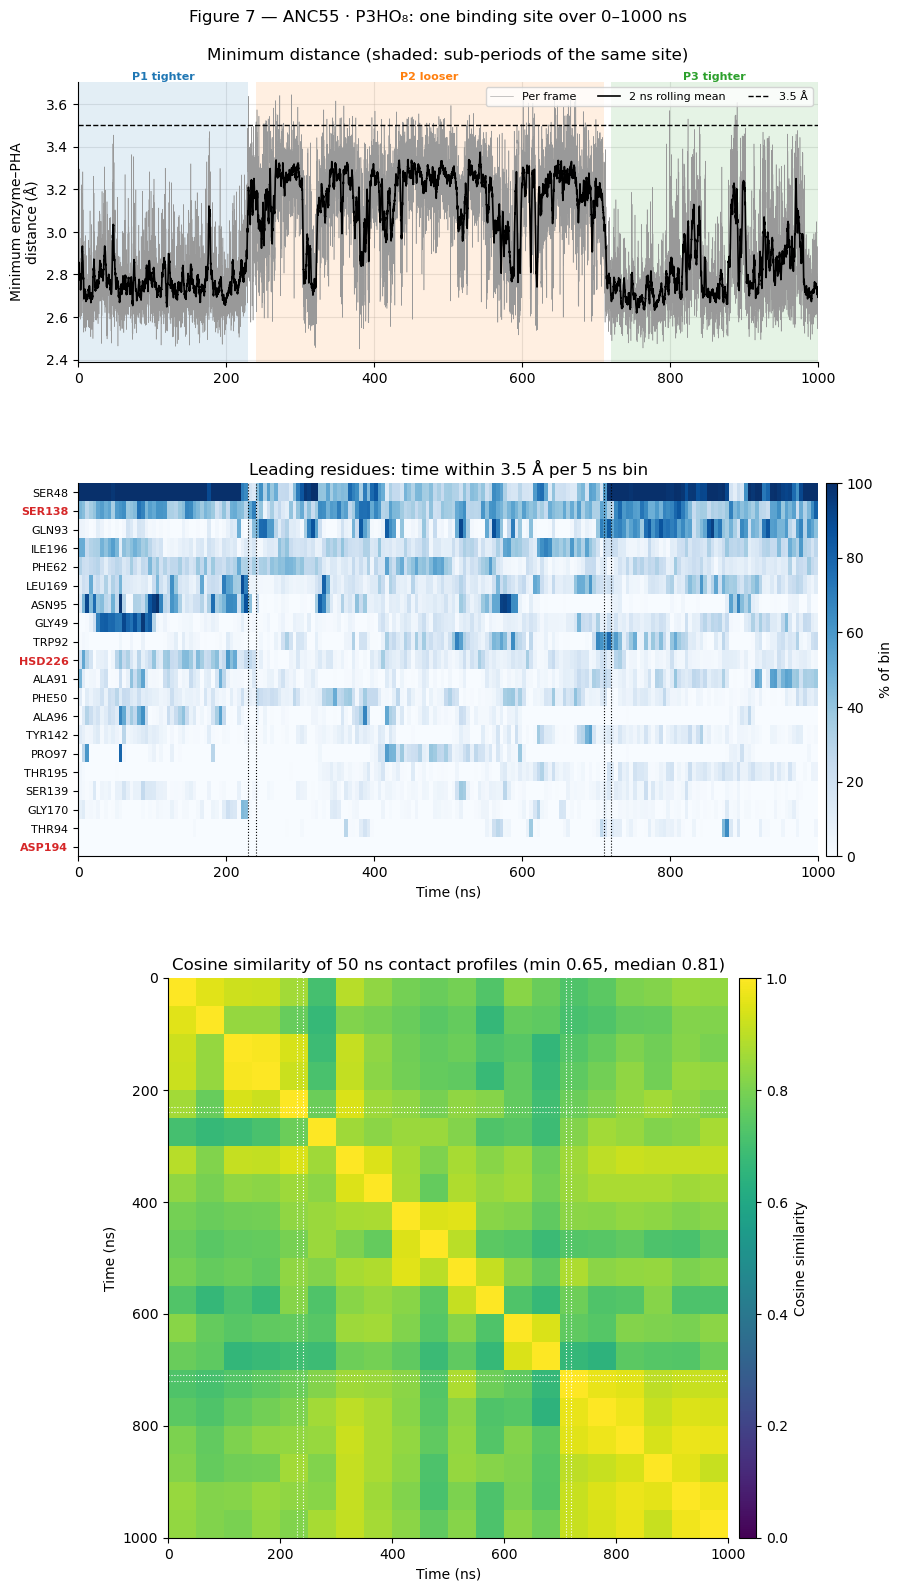

50 ns contact-profile similarity: min 0.65, median 0.81 (1 = same residues).


,group,min_distance_median_A,min_distance_mean_A,percent_frames_within_3p5A
0,0–1000 ns,2.92,2.97,98.75
1,P1 tighter (0–230 ns),2.74,2.77,100.00
2,P2 looser (240–710 ns),3.21,3.16,97.51
3,P3 tighter (720–1000 ns),2.75,2.81,99.79


In [4]:
n_roll = int(round(SMOOTH_NS / DT)) + 1
roll = lambda v, n=n_roll: pd.Series(v).rolling(n, center=True, min_periods=1).mean().to_numpy()
gmin_roll = roll(GMIN)
edges5 = np.arange(FULL_RANGE[0], FULL_RANGE[1] + 1e-9, HEATMAP_BIN_NS)
edges50 = np.arange(FULL_RANGE[0], FULL_RANGE[1] + 1e-9, PROFILE_BIN_NS)
occ5 = np.array([occupancy_percent((a, b)) for a, b in zip(edges5[:-1], edges5[1:])])      # bins x residues, %
occ50 = np.array([occupancy_percent((a, b)) for a, b in zip(edges50[:-1], edges50[1:])])
TRIAD_IDX = [int(np.flatnonzero(residues.resid.to_numpy() == i)[0]) for _, i, _ in ACTIVE_SITE.values()]
leading = (occ50 >= LEADING_PERCENT).any(axis=0); leading[TRIAD_IDX] = True
lead_idx = np.flatnonzero(leading)[np.argsort(-OCC_ALL[leading], kind='stable')]
norm50 = np.linalg.norm(occ50, axis=1)
SIM50 = (occ50 @ occ50.T) / np.outer(norm50, norm50)
off = SIM50[~np.eye(len(SIM50), dtype=bool)]
SIM_MIN, SIM_MEDIAN = float(off.min()), float(np.median(off))

fig = plt.figure(figsize=(FIGSIZE[0] * 1.25, 16))
gs = fig.add_gridspec(3, 1, height_ratios=[3, max(3.0, 0.2 * len(lead_idx)), 6], hspace=0.3)
ax = fig.add_subplot(gs[0]); shade_periods(ax, label=True)
ax.plot(T, GMIN, color='0.6', lw=0.4, label='Per frame')
ax.plot(T, gmin_roll, color='k', lw=1.2, label=f'{SMOOTH_NS:g} ns rolling mean')
ax.axhline(CONTACT_CUTOFF_A, color='k', ls='--', lw=1, label=f'{CONTACT_CUTOFF_A:g} Å')
ax.set(xlim=FULL_RANGE, ylabel='Minimum enzyme–PHA\ndistance (Å)')
ax.set_title('Minimum distance (shaded: sub-periods of the same site)', pad=16)
ax.legend(loc='upper right', fontsize=8, ncol=3); tidy(ax)
ax = fig.add_subplot(gs[1], sharex=ax)
im = ax.imshow(occ5[:, lead_idx].T, aspect='auto', cmap='Blues', vmin=0, vmax=100, interpolation='nearest',
               extent=[edges5[0], edges5[-1], len(lead_idx), 0])
ax.set_yticks(np.arange(len(lead_idx)) + 0.5); ax.set_yticklabels(RES_LABELS[lead_idx], fontsize=8)
colour_triad_ticks(ax.get_yticklabels())
for b in sorted({x for w in PERIODS.values() for x in w} - set(FULL_RANGE)): ax.axvline(b, color='k', ls=':', lw=0.8)
ax.set(xlabel='Time (ns)', title=f'Leading residues: time within {CONTACT_CUTOFF_A:g} Å per {HEATMAP_BIN_NS:g} ns bin')
cax = ax.inset_axes([1.01, 0, 0.015, 1]); fig.colorbar(im, cax=cax, label='% of bin')
ax = fig.add_subplot(gs[2])
im = ax.imshow(SIM50, cmap='viridis', vmin=0, vmax=1, extent=[edges50[0], edges50[-1], edges50[-1], edges50[0]])
for b in sorted({x for w in PERIODS.values() for x in w} - set(FULL_RANGE)):
    ax.axvline(b, color='w', ls=':', lw=0.8); ax.axhline(b, color='w', ls=':', lw=0.8)
ax.set(xlabel='Time (ns)', ylabel='Time (ns)',
       title=f'Cosine similarity of {PROFILE_BIN_NS:g} ns contact profiles (min {SIM_MIN:.2f}, median {SIM_MEDIAN:.2f})')
cax = ax.inset_axes([1.02, 0, 0.03, 1]); fig.colorbar(im, cax=cax, label='Cosine similarity')
fig.suptitle('Figure 7 — ANC55 · P3HO₈: one binding site over 0–1000 ns', y=0.995)
fig.subplots_adjust(top=0.95, bottom=0.04, left=0.14, right=0.88)
save_png(fig, 'fig7_one_site_over_time.png')
display(fig); plt.close(fig)

period_of = np.full(len(T), '', dtype=object)
for p, w in PERIODS.items(): period_of[in_window(T, w)] = p
save_csv(pd.DataFrame({'frame': FRAMES, 'time_ns': T, 'min_distance_A': GMIN, 'min_distance_rolling_A': gmin_roll,
                       'period': period_of}), 'fig7_min_distance.csv')
save_csv(pd.DataFrame(occ5[:, lead_idx], columns=RES_LABELS[lead_idx]).assign(bin_start_ns=edges5[:-1], bin_end_ns=edges5[1:]),
         'fig7_leading_residues_5ns_bins.csv')
save_csv(pd.DataFrame(occ50, columns=RES_LABELS).assign(bin_start_ns=edges50[:-1], bin_end_ns=edges50[1:]),
         'fig7_all_residues_50ns_bins.csv')
save_csv(pd.DataFrame(SIM50, columns=[f'{a:g}-{b:g}' for a, b in zip(edges50[:-1], edges50[1:])]).assign(
         bin_start_ns=edges50[:-1]), 'fig7_similarity_50ns.csv')
stats7 = pd.DataFrame([{'group': GROUP_LABEL[g], 'min_distance_median_A': np.median(GMIN[m]), 'min_distance_mean_A': GMIN[m].mean(),
                        'percent_frames_within_3p5A': 100 * (GMIN[m] <= CONTACT_CUTOFF_A).mean()}
                       for g, m in group_masks(T).items()])
save_csv(stats7, 'fig7_min_distance_by_period.csv')
print(f'50 ns contact-profile similarity: min {SIM_MIN:.2f}, median {SIM_MEDIAN:.2f} (1 = same residues).')
display(stats7.round(2))

### Figure 8 — Leading residues

**Question:** which enzyme residues hold the PHA, and does that change between the tighter and looser sub-periods? Occupancy is the time-weighted percentage of time in which any heavy atom of a residue is within the cutoff of any PHA heavy atom, as in the ANC45 notebook. **How to read it:** the left panel shows the top 15 residues plus the active site over 0–1000 ns at ≤3.5 Å (dark) and ≤4.5 Å (light); the right panel shows the same residues' ≤3.5 Å occupancy in P1, P2 and P3. Active-site residues are labelled in bold red.

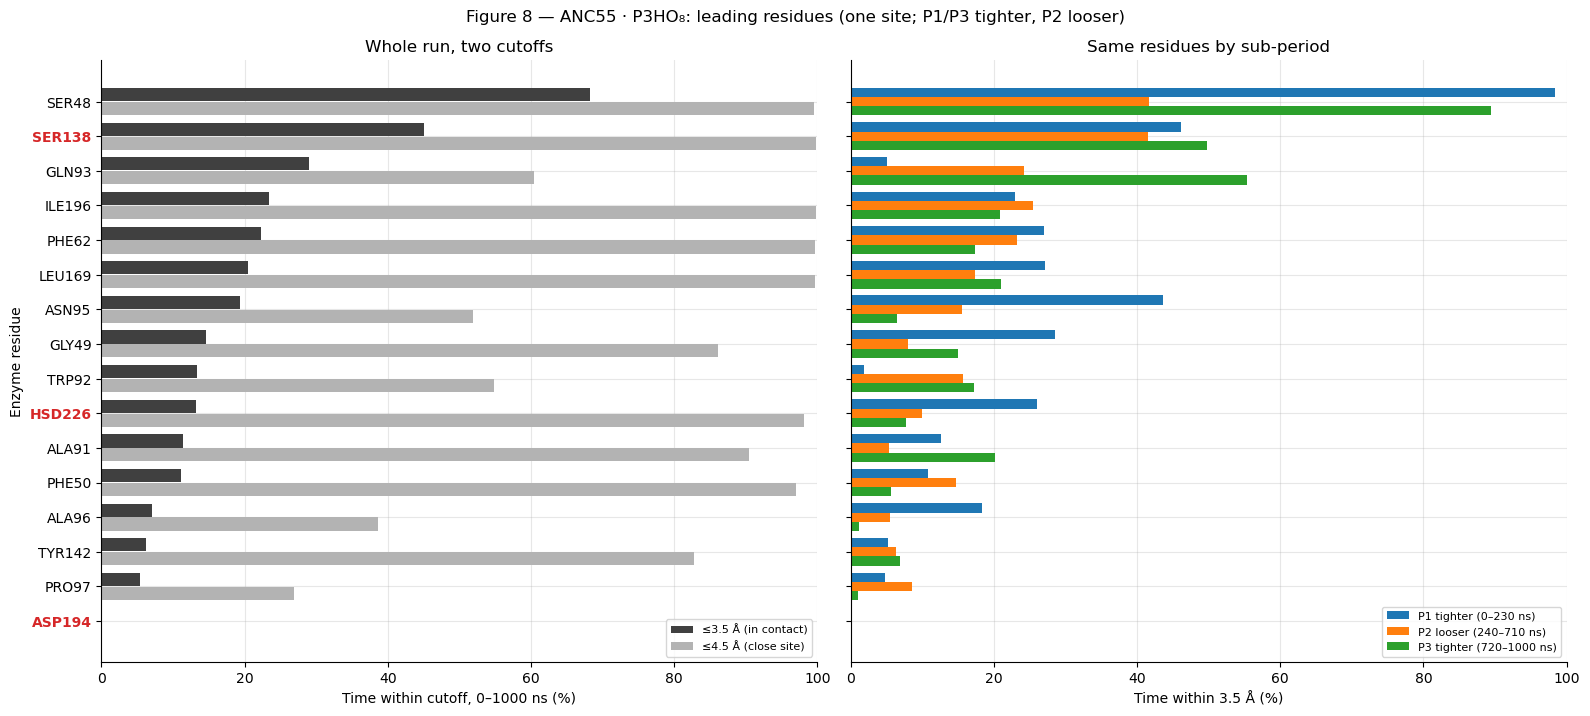

Reference check passed: SER48 68.2 %, SER138 45.1 %, GLN93 29.1 %


,resname,resid,occupancy_3p5A_0_1000ns,occupancy_4p5A_0_1000ns,occupancy_3p5A_P1,occupancy_3p5A_P2,occupancy_3p5A_P3
47,SER,48,68.2,99.6,98.3,41.7,89.5
137,SER,138,45.1,99.8,46.1,41.5,49.7
92,GLN,93,29.1,60.5,5.2,24.3,55.4
195,ILE,196,23.4,99.8,23.0,25.5,20.9
61,PHE,62,22.4,99.6,27.0,23.2,17.4
168,LEU,169,20.5,99.7,27.2,17.3,21.0
94,ASN,95,19.4,51.9,43.7,15.5,6.5
48,GLY,49,14.7,86.1,28.5,8.0,14.9
91,TRP,92,13.3,54.9,1.9,15.7,17.3
225,HSD,226,13.2,98.1,26.0,9.9,7.7


In [5]:
occ = residues[['resindex', 'resid', 'resname']].copy()
occ['occupancy_3p5A_0_1000ns'] = OCC_ALL
occ['occupancy_4p5A_0_1000ns'] = occupancy_percent(FULL_RANGE, CLOSE_CUTOFF_A)
for p, w in PERIODS.items():
    occ[f'occupancy_3p5A_{p}'] = occupancy_percent(w)
    occ[f'occupancy_4p5A_{p}'] = occupancy_percent(w, CLOSE_CUTOFF_A)
occ['active_site'] = residues.active_site.astype(str).str.lower().eq('true') | occ.index.isin(TRIAD_IDX)

bad = []
for (resname, resid), ref in REFERENCE_OCCUPANCY.items():
    got = occ.loc[(occ.resname == resname) & (occ.resid == resid), 'occupancy_3p5A_0_1000ns'].iloc[0]
    if abs(got - ref) > 0.05: bad.append(f'{resname}{resid}: {got:.2f} % vs {ref} %')
if bad: raise ValueError('Reference occupancies not reproduced:\n' + '\n'.join(bad))

shown = list(np.argsort(-OCC_ALL, kind='stable')[:TOP_N_RESIDUES]) + [i for i in TRIAD_IDX if i not in np.argsort(-OCC_ALL, kind='stable')[:TOP_N_RESIDUES]]
table8 = occ.iloc[shown].copy(); labels8 = (table8.resname + table8.resid.astype(str)).tolist(); y = np.arange(len(table8))

fig, axes = plt.subplots(1, 2, figsize=(2 * FIGSIZE[0], max(FIGSIZE[1], 0.36 * len(table8) + 1.5)), sharey=True)
ax = axes[0]
ax.barh(y - 0.2, table8.occupancy_3p5A_0_1000ns, height=0.38, color='0.25', label=f'≤{CONTACT_CUTOFF_A:g} Å (in contact)')
ax.barh(y + 0.2, table8.occupancy_4p5A_0_1000ns, height=0.38, color='0.7', label=f'≤{CLOSE_CUTOFF_A:g} Å (close site)')
ax.set(yticks=y, yticklabels=labels8, xlim=(0, 100), xlabel='Time within cutoff, 0–1000 ns (%)', ylabel='Enzyme residue',
       title='Whole run, two cutoffs')
ax.invert_yaxis(); ax.legend(loc='lower right', fontsize=8)
ax = axes[1]
group_bars(ax, labels8, {p: table8[f'occupancy_3p5A_{p}'].to_numpy() for p in PERIODS}, groups=list(PERIODS), horizontal=True)
ax.set(xlim=(0, 100), xlabel=f'Time within {CONTACT_CUTOFF_A:g} Å (%)', title='Same residues by sub-period')
ax.legend(loc='lower right', fontsize=8)
colour_triad_ticks(axes[0].get_yticklabels())
for ax in axes: tidy(ax)
fig.suptitle('Figure 8 — ANC55 · P3HO₈: leading residues (one site; P1/P3 tighter, P2 looser)')
fig.tight_layout()
save_png(fig, 'fig8_leading_residues.png')
display(fig); plt.close(fig)
save_csv(occ, 'fig8_residue_occupancy_all.csv')
save_csv(table8, 'fig8_residues_shown.csv')
print('Reference check passed:', ', '.join(f'{r}{i} {ref} %' for (r, i), ref in REFERENCE_OCCUPANCY.items()))
display(table8[['resname', 'resid', 'occupancy_3p5A_0_1000ns', 'occupancy_4p5A_0_1000ns'] + [f'occupancy_3p5A_{p}' for p in PERIODS]].round(1))

### Figure 9 — Enzyme–PHA interaction energy

**Question:** how strongly do the enzyme and the PHA attract each other, and is the attraction stronger in the tighter sub-periods? One frame every 1 ns over 0–1000 ns is re-evaluated with `gmx mdrun -rerun` on the CPU, using the production settings plus energy groups PROT and LIG. **How to read it:** the left panel shows the Coulomb, Lennard-Jones and summed enzyme–PHA energies over time (more negative = stronger attraction) with P1–P3 shaded; the right panel compares means for 0–1000 ns and each sub-period, with error bars = SD of 10 ns block means. This is the short-range interaction energy only (1.2 nm cut-off, force-switch for LJ, real-space PME for Coulomb); long-range PME and entropy are not included, so it is not a binding free energy, and it describes this one trajectory only.

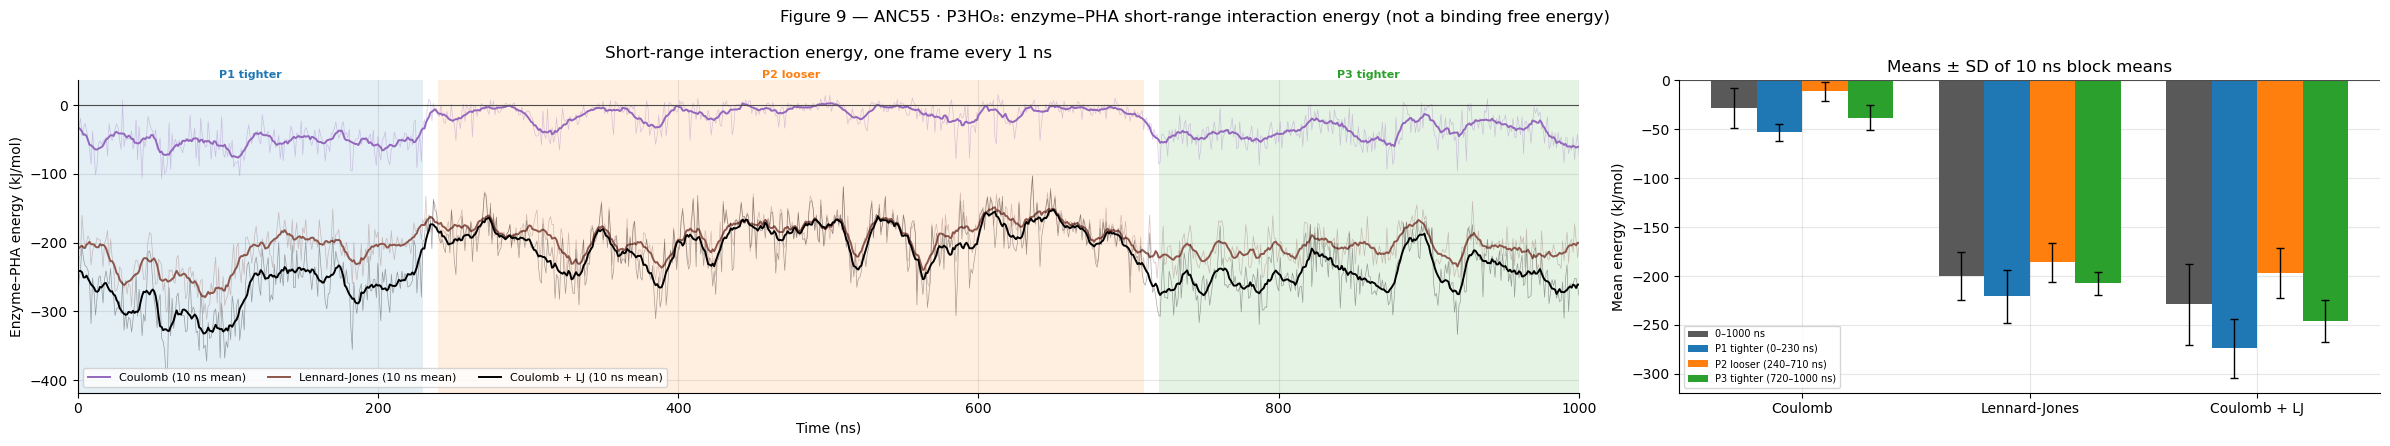

Rerun check: Potential within a median 0.10 % (max 0.12 %) of the production energies.
Rerun folder: /Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_new_Enzyme/ANC55_P3HO8_gromacs/analysis/binding_site_ANC55_P3HO8/fig9_rerun_0-1000ns_every1ns (loaded saved results)


label,0–1000 ns,P1 tighter (0–230 ns),P2 looser (240–710 ns),P3 tighter (720–1000 ns)
component,,,,
Coulomb,-28.8,-53.1,-11.5,-38.3
Coulomb + LJ,-228.9,-273.9,-197.3,-245.9
Lennard-Jones,-200.1,-220.8,-185.9,-207.6


In [6]:
ENERGY_TERMS = {'Coul-SR:PROT-LIG': 'coulomb_sr_kj_mol', 'LJ-SR:PROT-LIG': 'lj_sr_kj_mol'}
ENERGY_FILE = RERUN_DIR / 'fig9_interaction_energy_frames.csv'
RERUN_COMMANDS = []
step = int(round(RERUN_STEP_NS / DT))
T9 = T[::step]

def run_gmx(args, log_name, stdin=''):
    cmd = [GMX] + [str(a) for a in args]
    r = subprocess.run(cmd, input=stdin, text=True, capture_output=True, cwd=RERUN_DIR)
    (RERUN_DIR / log_name).write_text('$ ' + ' '.join(cmd) + '\n\n' + r.stdout + '\n' + r.stderr)
    if r.returncode: raise RuntimeError(f"{' '.join(cmd[:2])} failed; see {RERUN_DIR / log_name}")
    RERUN_COMMANDS.append(' '.join(cmd))

def read_xvg(path):
    names, rows = [], []
    for line in Path(path).read_text().splitlines():
        if line.startswith('@') and ' legend "' in line: names.append(line.split('"')[1])
        elif line.strip() and line[0] not in '#@': rows.append([float(x) for x in line.split()])
    return pd.DataFrame(rows, columns=['time_ps'] + names)

if RUN_RERUN:
    if GMX is None: raise RuntimeError('gmx not found on PATH')
    if RERUN_DIR.exists(): raise FileExistsError(f'{RERUN_DIR} exists; delete it yourself or change RERUN_STEP_NS')
    rec = file_record(PATHS['edr'])
    if PATHS['edr'].resolve() != Path(summary_json['inputs']['edr']).resolve() or [rec['size'], rec['mtime_ns']] != summary_json['input_size_mtime_ns']['edr']:
        raise ValueError('Production EDR differs from the saved provenance')
    RERUN_DIR.mkdir(parents=True)
    # 1. New index: the original groups (SOLU, SOLV, SYSTEM; tc-grps needs them) plus PROT and LIG. index.ndx is not modified.
    groups = {name: body.split() for name, body in re.findall(r'\[\s*(\S+)\s*\]([^\[]*)', (SYSTEM_DIR / 'index.ndx').read_text())}
    if 'PROT' in groups or 'LIG' in groups: raise ValueError('index.ndx already has PROT or LIG groups')
    groups['PROT'] = [str(i + 1) for i in U.select_atoms('protein').indices]
    groups['LIG'] = [str(i + 1) for i in LIG.indices]
    with open(RERUN_DIR / 'rerun_index.ndx', 'x') as f:
        for name, ids in groups.items():
            f.write(f'[ {name} ]\n' + '\n'.join(' '.join(ids[i:i + 15]) for i in range(0, len(ids), 15)) + '\n')
    # 2. Copy of step7_production.mdp with energy groups added.
    mdp = (SYSTEM_DIR / 'step7_production.mdp').read_text()
    if 'energygrps' in mdp.lower(): raise ValueError('step7_production.mdp already defines energygrps')
    (RERUN_DIR / 'rerun.mdp').write_text(mdp.rstrip('\n') + '\n\n; added for the Figure 9 rerun\nenergygrps              = PROT LIG\n')
    # 3. grompp with the step7 production inputs, then confirm rerun.tpr differs from step7_production.tpr only in energy groups.
    run_gmx(['grompp', '-f', 'rerun.mdp', '-c', SYSTEM_DIR / 'step6.2_npt.gro', '-p', SYSTEM_DIR / 'topol.top',
             '-n', 'rerun_index.ndx', '-o', 'rerun.tpr', '-po', 'rerun_mdout.mdp', '-maxwarn', '0'], 'grompp.log')
    run_gmx(['check', '-s1', PATHS['tpr'], '-s2', 'rerun.tpr'], 'tpr_check.log')
    diffs = {re.sub(r'\[\d+\]', '[i]', l.split('(')[0].strip()) for l in (RERUN_DIR / 'tpr_check.log').read_text().splitlines()
             if re.search(r'\(.* - .*\)', l)}
    unexpected = diffs - {'inputrec->ld_seed', 'inputrec->grpopts.ngener', 'grps[i].nr', 'ngrpnr[i]'}
    if unexpected: raise RuntimeError(f'rerun.tpr differs from step7_production.tpr beyond energy groups: {unexpected}')
    # 4. Extract one frame per RERUN_STEP_NS, rerun on CPU (energy groups need the CPU), read energies.
    s, e = FULL_RANGE
    run_gmx(['trjconv', '-f', PATHS['xtc'], '-s', 'rerun.tpr', '-b', f'{s * 1000:g}', '-e', f'{e * 1000:g}',
             '-dt', f'{RERUN_STEP_NS * 1000:g}', '-o', 'rerun_frames.xtc'], 'trjconv.log', stdin='0\n')
    run_gmx(['mdrun', '-s', 'rerun.tpr', '-rerun', 'rerun_frames.xtc', '-deffnm', 'rerun', '-nb', 'cpu', '-pme', 'cpu',
             '-ntmpi', '1', '-ntomp', GMX_THREADS], 'mdrun.log')
    run_gmx(['energy', '-f', 'rerun.edr', '-o', 'energy.xvg'], 'energy.log', stdin='\n'.join(list(ENERGY_TERMS) + ['Potential']) + '\n\n')
    run_gmx(['energy', '-f', PATHS['edr'], '-b', f'{s * 1000:g}', '-e', f'{e * 1000:g}', '-o', 'production_potential.xvg'],
            'production_energy.log', stdin='Potential\n\n')
    x = read_xvg(RERUN_DIR / 'energy.xvg')
    if len(x) != len(T9) or not np.allclose(x.time_ps / 1000, T9, atol=1e-6):
        raise ValueError('Rerun frames do not match the expected 1 ns frames')
    prod = read_xvg(RERUN_DIR / 'production_potential.xvg')
    prod = prod.assign(t=prod.time_ps.round(3)).set_index('t').Potential.loc[x.time_ps.round(3)].to_numpy()
    (RERUN_DIR / 'production_potential.xvg').unlink()   # 500 001 rows; the matching rows are kept in the CSV
    if not KEEP_RERUN_XTC: (RERUN_DIR / 'rerun_frames.xtc').unlink()
    e9 = pd.DataFrame({'time_ns': x.time_ps / 1000, **{col: x[term] for term, col in ENERGY_TERMS.items()},
                       'potential_rerun_kj_mol': x.Potential, 'potential_production_kj_mol': prod})
    e9['total_sr_kj_mol'] = e9.coulomb_sr_kj_mol + e9.lj_sr_kj_mol
    e9.to_csv(ENERGY_FILE, index=False)
    gmx_version = subprocess.run([GMX, '--version'], capture_output=True, text=True).stdout
    (RERUN_DIR / 'rerun_provenance.json').write_text(json.dumps({
        'created': datetime.now().isoformat(timespec='seconds'), 'range_ns': FULL_RANGE, 'step_ns': RERUN_STEP_NS,
        'commands': RERUN_COMMANDS, 'gromacs': next((l.strip() for l in gmx_version.splitlines() if 'GROMACS version' in l), ''),
        'tpr_differences_vs_production': sorted(diffs),
        'inputs': {k: file_record(p) for k, p in {'tpr': PATHS['tpr'], 'xtc': PATHS['xtc'], 'edr': PATHS['edr'],
                   'mdp': SYSTEM_DIR / 'step7_production.mdp', 'top': SYSTEM_DIR / 'topol.top', 'gro': SYSTEM_DIR / 'step6.2_npt.gro',
                   'index': SYSTEM_DIR / 'index.ndx'}.items()},
        'outputs': {p.name: sha256(p) for p in sorted(RERUN_DIR.iterdir()) if p.is_file() and p.suffix in ('.csv', '.tpr', '.ndx', '.mdp')}},
        indent=2, default=str))
else:
    if not ENERGY_FILE.is_file():
        raise FileNotFoundError(f'No saved rerun results in {RERUN_DIR}. Set RUN_RERUN = True once to create them.')
    e9 = pd.read_csv(ENERGY_FILE)
    if len(e9) != len(T9) or not np.allclose(e9.time_ns, T9, atol=1e-6):
        raise ValueError('Saved rerun results do not match the expected 1 ns frames')

# Check: rerun Potential agrees with the production energies (differences come from XTC coordinate rounding).
pot_rel = (e9.potential_rerun_kj_mol - e9.potential_production_kj_mol).abs() / e9.potential_production_kj_mol.abs() * 100
if pot_rel.median() > 0.5:
    raise RuntimeError(f'Rerun Potential differs from production by a median {pot_rel.median():.2f} %: check the setup')

COMPONENTS = {'coulomb_sr_kj_mol': ('Coulomb', 'tab:purple'), 'lj_sr_kj_mol': ('Lennard-Jones', 'tab:brown'),
              'total_sr_kj_mol': ('Coulomb + LJ', 'k')}
rows9 = []
for g in GROUPS:
    s, e = GROUP_WINDOW[g]; w = e9.loc[in_window(e9.time_ns, (s, e))]
    n_blocks = int(round((e - s) / BLOCK_NS))
    block = np.minimum(((w.time_ns - s) // BLOCK_NS).astype(int), n_blocks - 1)
    means = w.groupby(block)[list(COMPONENTS)].mean()
    for col, (name, _) in COMPONENTS.items():
        rows9.append({'group': g, 'label': GROUP_LABEL[g], 'component': name, 'mean_kj_mol': w[col].mean(),
                      'block_sd_kj_mol': means[col].std(ddof=1), 'frame_sd_kj_mol': w[col].std(ddof=1),
                      'blocks': len(means), 'block_ns': BLOCK_NS, 'frames': len(w)})
stats9 = pd.DataFrame(rows9)

fig = plt.figure(figsize=(3 * FIGSIZE[0], FIGSIZE[1]))
gs = fig.add_gridspec(1, 3)
ax = fig.add_subplot(gs[0, :2]); shade_periods(ax, label=True)
n9 = int(round(BLOCK_NS / RERUN_STEP_NS)) + 1
for col, (name, colour) in COMPONENTS.items():
    ax.plot(e9.time_ns, e9[col], color=colour, lw=0.5, alpha=0.35)
    ax.plot(e9.time_ns, roll(e9[col].to_numpy(), n9), color=colour, lw=1.4, label=f'{name} ({BLOCK_NS:g} ns mean)')
ax.axhline(0, color='0.3', lw=0.8)
ax.set(xlabel='Time (ns)', ylabel='Enzyme–PHA energy (kJ/mol)', xlim=FULL_RANGE)
ax.set_title(f'Short-range interaction energy, one frame every {RERUN_STEP_NS:g} ns', pad=16)
ax.legend(fontsize=8, loc='lower left', ncol=3); tidy(ax)
ax = fig.add_subplot(gs[0, 2])
names9 = [n for n, _ in COMPONENTS.values()]
vals = {g: stats9.loc[stats9.group == g, 'mean_kj_mol'].to_numpy() for g in GROUPS}
errs = {g: stats9.loc[stats9.group == g, 'block_sd_kj_mol'].to_numpy() for g in GROUPS}
pos = group_bars(ax, names9, vals)
wbar = 0.8 / len(GROUPS)
for j, g in enumerate(GROUPS):
    ax.errorbar(pos + (j - (len(GROUPS) - 1) / 2) * wbar, vals[g], yerr=errs[g], fmt='none', ecolor='k', capsize=3, lw=1)
ax.axhline(0, color='0.3', lw=0.8)
ax.set(xticks=pos, xticklabels=names9, ylabel='Mean energy (kJ/mol)', title=f'Means ± SD of {BLOCK_NS:g} ns block means')
ax.legend(fontsize=7, loc='lower left'); tidy(ax)
fig.suptitle('Figure 9 — ANC55 · P3HO₈: enzyme–PHA short-range interaction energy (not a binding free energy)')
fig.tight_layout()
save_png(fig, 'fig9_interaction_energy.png')
display(fig); plt.close(fig)
save_csv(e9, 'fig9_interaction_energy_frames.csv')
save_csv(stats9, 'fig9_interaction_energy_summary.csv')
print(f"Rerun check: Potential within a median {pot_rel.median():.2f} % (max {pot_rel.max():.2f} %) of the production energies.")
print('Rerun folder:', RERUN_DIR, '(computed now)' if RUN_RERUN else '(loaded saved results)')
display(stats9.pivot(index='component', columns='label', values='mean_kj_mol').round(1))

### Figure 10 — How the PHA is held

**Question:** how many residues and hydrogen bonds hold the PHA, and does a hydrogen bond to SER48 explain why the minimum distance sits near 2.7 Å in P1/P3 but near 3.2 Å in P2? Residue counts come from the saved residue distances; hydrogen bonds are found with MDAnalysis every 0.5 ns over 0–1000 ns with the ANC45 criteria (donor–acceptor ≤ 3.0 Å, D–H–A angle ≥ 150°, periodic box applied, protein and PHA as donor or acceptor). **How to read it:** top row, residues in contact and hydrogen bonds over time (5 ns means) and the minimum distance in frames with and without a SER48 hydrogen bond; bottom row, means ± SD per sub-period and the most frequent hydrogen-bond partners as % of frames.

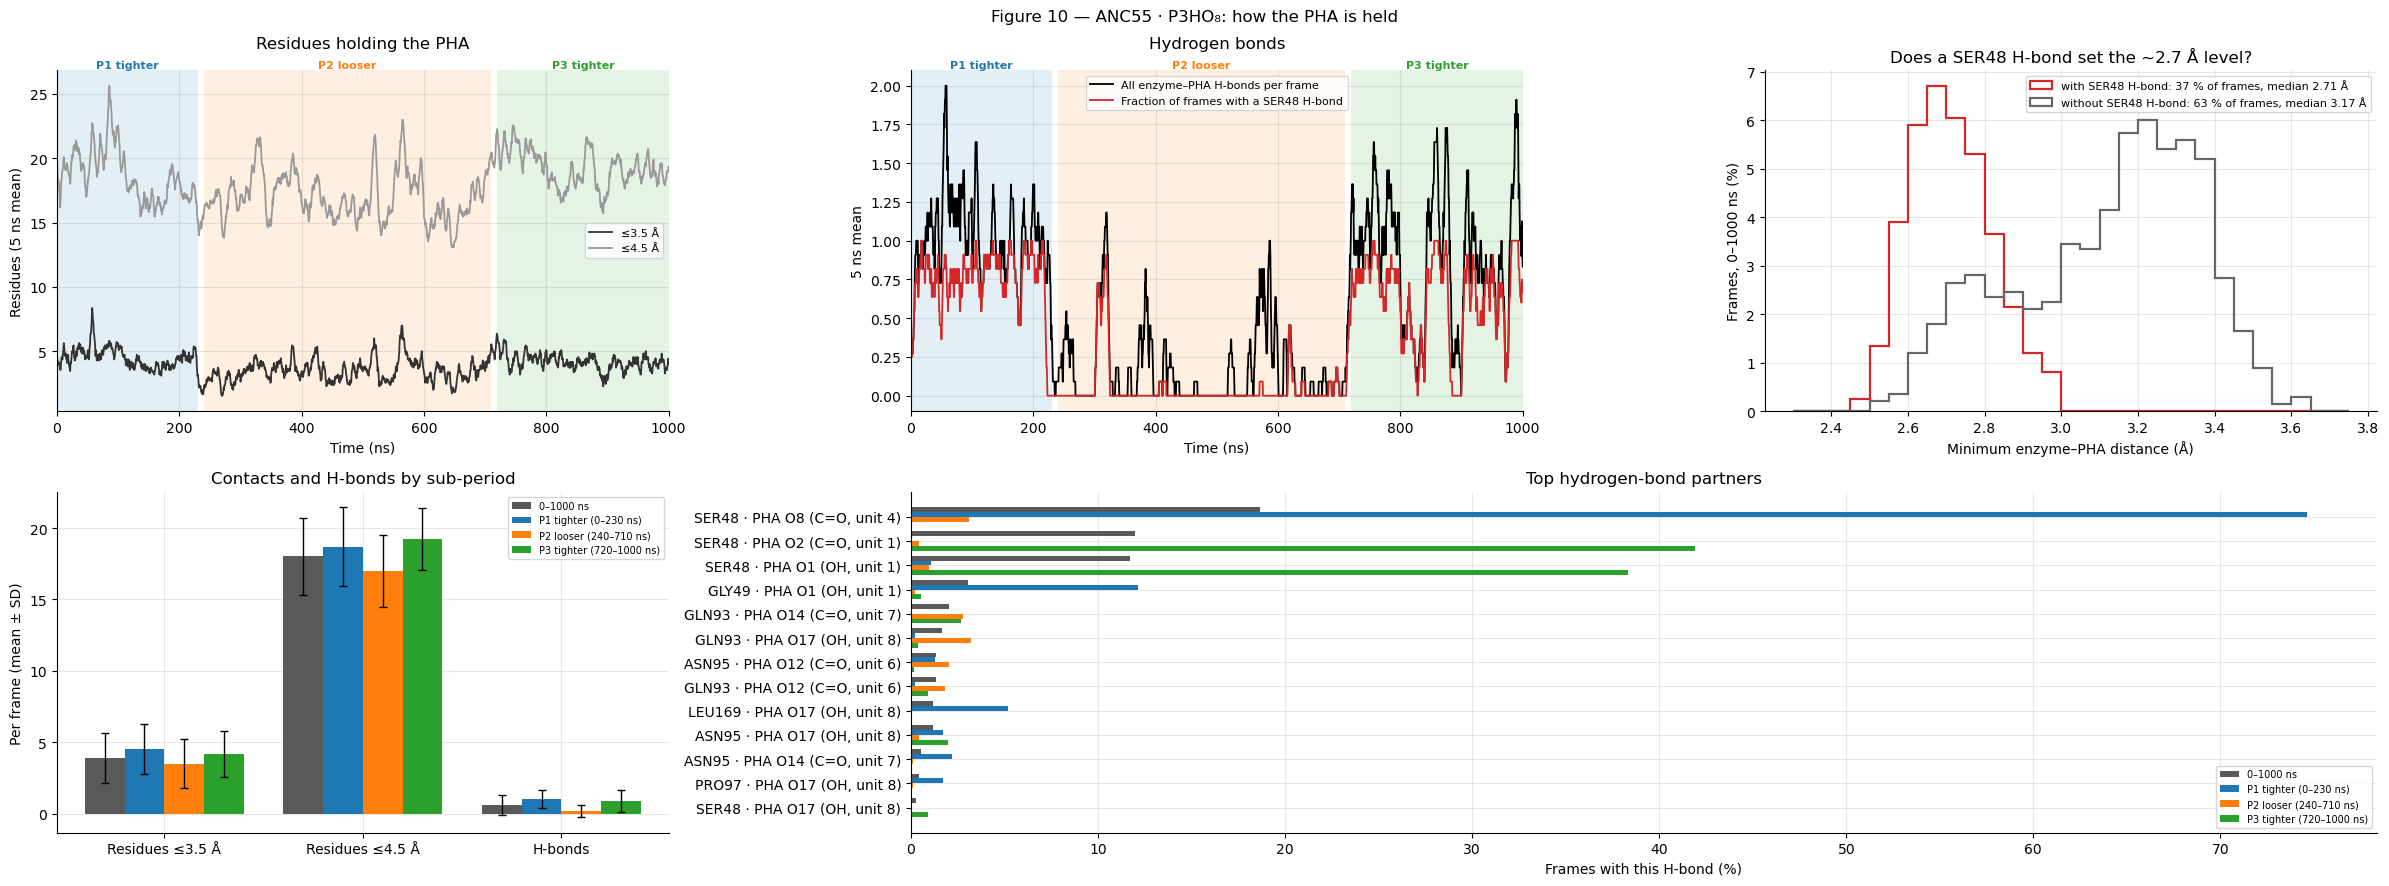

PHA donors used: ['O1–H1', 'O17–H114'] | 382 donor hydrogens, 374 acceptors, 2001 frames


label,0–1000 ns,P1 tighter (0–230 ns),P2 looser (240–710 ns),P3 tighter (720–1000 ns)
variable,,,,
hbonds,0.57,1.02,0.17,0.90
residues_within_3p5A,3.92,4.52,3.48,4.17
residues_within_4p5A,18.02,18.69,17.00,19.22


label,0–1000 ns,P1 tighter (0–230 ns),P2 looser (240–710 ns),P3 tighter (720–1000 ns)
frames_with_SER48_hbond_percent,37.23,75.05,4.46,62.57
median_min_distance_A,2.91,2.73,3.21,2.75
median_min_distance_with_SER48_hbond_A,2.71,2.71,2.72,2.70
median_min_distance_without_SER48_hbond_A,3.17,2.89,3.22,2.96
SER48_closest_residue_percent,49.83,79.18,17.64,80.39
frames_min_below_3A_percent,55.37,90.24,22.21,82.71
of_those_with_SER48_hbond_percent,67.24,83.17,20.10,75.65


SER48 H-bond present in 75 % (P1), 4 % (P2) and 63 % (P3) of frames; median minimum distance 2.71 Å with it and 3.17 Å without it. Of all frames below 3.0 Å, 67 % have the SER48 H-bond.


In [7]:
from MDAnalysis.analysis.hydrogenbonds import HydrogenBondAnalysis

step10 = int(round(HBOND_STEP_NS / DT))
I10 = np.arange(0, len(T), step10); F10, T10 = FRAMES[I10], T[I10]
N35, N45 = (DIST[I10] <= CONTACT_CUTOFF_A).sum(axis=1), (DIST[I10] <= CLOSE_CUTOFF_A).sum(axis=1)

# Hydrogen bonds, as in the ANC45 notebook. Donor hydrogens: every H bonded to N or O (protein; PHA OH groups).
# Acceptors: all protein O, protein side-chain N without H (e.g. HSD NE2), and all PHA oxygens.
PROTEIN = U.select_atoms('protein')
polar_h = [a.index for a in PROTEIN + LIG
           if a.element == 'H' and len(a.bonded_atoms) == 1 and a.bonded_atoms[0].element in ('N', 'O')]
acceptors = [a.index for a in PROTEIN
             if a.element == 'O' or (a.element == 'N' and a.name != 'N' and 'H' not in a.bonded_atoms.elements)]
acceptors += list(LIG.select_atoms('element O').indices)
LIG_DONORS = [f'{U.atoms[i].bonded_atoms[0].name}–{U.atoms[i].name}' for i in polar_h if U.atoms[i].resname == 'LIG']
hba = HydrogenBondAnalysis(U, between=['protein', 'resname LIG'],
                           hydrogens_sel='index ' + ' '.join(map(str, polar_h)),
                           acceptors_sel='index ' + ' '.join(map(str, acceptors)),
                           d_a_cutoff=HBOND_DA_CUTOFF_A, d_h_a_angle_cutoff=HBOND_ANGLE_DEG, update_selections=False)
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='No hydrogen bonds were found')   # printed for frames without any H-bond
    hba.run(frames=[int(f) for f in F10])

O_ROLE = {'OG2D1': 'C=O', 'OG302': 'ester O', 'OG311': 'OH'}
ATOM_UNIT = {a.index: k + 1 for k, u in enumerate(UNITS) for a in u}
rows = []
for frame, d, h, acc, dist, ang in hba.results.hbonds:
    donor, acceptor = U.atoms[int(d)], U.atoms[int(acc)]
    prot, pha = (donor, acceptor) if donor.resname != 'LIG' else (acceptor, donor)
    rows.append({'frame': int(frame), 'direction': 'protein donor' if donor.resname != 'LIG' else 'PHA donor',
                 'protein_residue': f'{prot.resname}{prot.resid}', 'protein_atom': prot.name,
                 'pha_atom': pha.name, 'pha_unit': ATOM_UNIT[pha.index],
                 'partner': f'{prot.resname}{prot.resid} · PHA {pha.name} ({O_ROLE.get(pha.type, pha.type)}, unit {ATOM_UNIT[pha.index]})',
                 'distance_A': dist, 'angle_deg': ang})
hbonds = pd.DataFrame(rows, columns=['frame', 'direction', 'protein_residue', 'protein_atom', 'pha_atom', 'pha_unit',
                                     'partner', 'distance_A', 'angle_deg'])
hbonds.insert(1, 'time_ns', T[hbonds.frame.to_numpy() - FRAMES[0]] if len(hbonds) else [])
hbonds.insert(2, 'period', period_of[hbonds.frame.to_numpy() - FRAMES[0]] if len(hbonds) else [])
HB = pd.Series(0, index=F10).add(hbonds.groupby('frame').size(), fill_value=0).loc[F10].to_numpy().astype(int)
focus = f'{HBOND_FOCUS_RESIDUE[0]}{HBOND_FOCUS_RESIDUE[1]}'
focus_frames = set(hbonds.loc[hbonds.protein_residue == focus, 'frame'])
HB_FOCUS = np.array([f in focus_frames for f in F10])
G10 = GMIN[I10]
CLOSEST = RES_LABELS[DIST[I10].argmin(axis=1)]
per_frame10 = pd.DataFrame({'frame': F10, 'time_ns': T10, 'period': period_of[I10], 'residues_within_3p5A': N35,
                            'residues_within_4p5A': N45, 'hbonds': HB, f'hbond_with_{focus}': HB_FOCUS,
                            'min_distance_A': G10, 'closest_residue': CLOSEST})
masks10 = group_masks(T10)
stats10 = pd.DataFrame([{'group': g, 'label': GROUP_LABEL[g], 'variable': name, 'mean': v[m].mean(), 'sd': v[m].std(ddof=1),
                         'median': np.median(v[m]), 'frames': int(m.sum())}
                        for g, m in masks10.items() for name, v in [('residues_within_3p5A', N35), ('residues_within_4p5A', N45), ('hbonds', HB)]])
partners = pd.concat([(hbonds.loc[hbonds.frame.isin(F10[m])].groupby('partner').frame.nunique() / m.sum() * 100).rename(g)
                      for g, m in masks10.items()], axis=1).fillna(0.0)
top_p = []
for g in GROUPS:
    for p in partners[g].nlargest(6).index:
        if partners.loc[p, g] > 0 and p not in top_p: top_p.append(p)
partners_shown = partners.loc[sorted(top_p, key=lambda p: -partners.loc[p, 'all'])]
focus_rows = []
for g, m in masks10.items():
    with_hb, without = G10[m & HB_FOCUS], G10[m & ~HB_FOCUS]
    focus_rows.append({'group': g, 'label': GROUP_LABEL[g], f'frames_with_{focus}_hbond_percent': 100 * HB_FOCUS[m].mean(),
                       'median_min_distance_A': np.median(G10[m]),
                       f'median_min_distance_with_{focus}_hbond_A': np.median(with_hb) if len(with_hb) else np.nan,
                       f'median_min_distance_without_{focus}_hbond_A': np.median(without) if len(without) else np.nan,
                       f'{focus}_closest_residue_percent': 100 * (CLOSEST[m] == focus).mean(),
                       'frames_min_below_3A_percent': 100 * (G10[m] < 3.0).mean(),
                       f'of_those_with_{focus}_hbond_percent': 100 * HB_FOCUS[m & (G10 < 3.0)].mean() if (m & (G10 < 3.0)).any() else np.nan})
focus10 = pd.DataFrame(focus_rows)

fig, axes = plt.subplots(2, 3, figsize=(3 * FIGSIZE[0], 2 * FIGSIZE[1]))
n10 = int(round(5.0 / HBOND_STEP_NS)) + 1
ax = axes[0, 0]; shade_periods(ax, label=True)
ax.plot(T10, roll(N35, n10), color='0.2', lw=1.3, label=f'≤{CONTACT_CUTOFF_A:g} Å')
ax.plot(T10, roll(N45, n10), color='0.6', lw=1.3, label=f'≤{CLOSE_CUTOFF_A:g} Å')
ax.set(xlim=FULL_RANGE, xlabel='Time (ns)', ylabel='Residues (5 ns mean)'); ax.set_title('Residues holding the PHA', pad=16)
ax.legend(fontsize=8, loc='center right')
ax = axes[0, 1]; shade_periods(ax, label=True)
ax.plot(T10, roll(HB, n10), color='k', lw=1.3, label='All enzyme–PHA H-bonds per frame')
ax.plot(T10, roll(HB_FOCUS.astype(float), n10), color='tab:red', lw=1.3, label=f'Fraction of frames with a {focus} H-bond')
ax.set(xlim=FULL_RANGE, xlabel='Time (ns)', ylabel='5 ns mean'); ax.set_title('Hydrogen bonds', pad=16)
ax.legend(fontsize=8, loc='upper center')
ax = axes[0, 2]
bins = np.arange(2.3, 3.75, 0.05)
for sel, colour, name in [(HB_FOCUS, 'tab:red', f'with {focus} H-bond'), (~HB_FOCUS, '0.4', f'without {focus} H-bond')]:
    if sel.any():
        ax.hist(G10[sel], bins=bins, weights=np.full(sel.sum(), 100 / len(G10)), histtype='step', lw=1.6, color=colour,
                label=f'{name}: {100 * sel.mean():.0f} % of frames, median {np.median(G10[sel]):.2f} Å')
ax.set(xlabel='Minimum enzyme–PHA distance (Å)', ylabel='Frames, 0–1000 ns (%)', title=f'Does a {focus} H-bond set the ~2.7 Å level?')
ax.legend(fontsize=8)
ax = axes[1, 0]
metrics = [('residues_within_3p5A', f'Residues ≤{CONTACT_CUTOFF_A:g} Å'), ('residues_within_4p5A', f'Residues ≤{CLOSE_CUTOFF_A:g} Å'), ('hbonds', 'H-bonds')]
pos = group_bars(ax, [n for _, n in metrics], {g: [stats10.loc[(stats10.group == g) & (stats10.variable == v), 'mean'].iloc[0] for v, _ in metrics] for g in GROUPS})
wbar = 0.8 / len(GROUPS)
for j, g in enumerate(GROUPS):
    ax.errorbar(pos + (j - (len(GROUPS) - 1) / 2) * wbar, [stats10.loc[(stats10.group == g) & (stats10.variable == v), 'mean'].iloc[0] for v, _ in metrics],
                yerr=[stats10.loc[(stats10.group == g) & (stats10.variable == v), 'sd'].iloc[0] for v, _ in metrics], fmt='none', ecolor='k', capsize=3, lw=1)
ax.set(xticks=pos, xticklabels=[n for _, n in metrics], ylabel='Per frame (mean ± SD)', title='Contacts and H-bonds by sub-period')
ax.legend(fontsize=7)
axes[1, 1].remove(); axes[1, 2].remove()
ax = fig.add_subplot(2, 3, (5, 6))
yy = group_bars(ax, list(partners_shown.index), {g: partners_shown[g].to_numpy() for g in GROUPS}, horizontal=True)
ax.set(yticks=yy, yticklabels=partners_shown.index, xlabel='Frames with this H-bond (%)', title='Top hydrogen-bond partners')
ax.invert_yaxis(); ax.legend(fontsize=7, loc='lower right')
colour_triad_ticks(ax.get_yticklabels())
for a in fig.axes: tidy(a)
fig.suptitle('Figure 10 — ANC55 · P3HO₈: how the PHA is held')
fig.tight_layout()
save_png(fig, 'fig10_contacts_hbonds.png')
display(fig); plt.close(fig)
save_csv(per_frame10, 'fig10_per_frame.csv')
save_csv(hbonds, 'fig10_hbonds_all.csv')
save_csv(partners.reset_index(names='partner').sort_values('all', ascending=False), 'fig10_hbond_partners.csv')
save_csv(stats10, 'fig10_summary.csv')
save_csv(focus10, f'fig10_{focus}_hbond_vs_min_distance.csv')
print('PHA donors used:', LIG_DONORS, f'| {len(polar_h)} donor hydrogens, {len(acceptors)} acceptors, {len(F10)} frames')
display(stats10.pivot(index='variable', columns='label', values='mean').round(2))
display(focus10.drop(columns='group').set_index('label').T.round(2))
f = focus10.set_index('group')
with_col, without_col = f'median_min_distance_with_{focus}_hbond_A', f'median_min_distance_without_{focus}_hbond_A'
print(f"{focus} H-bond present in {f.loc['P1', f'frames_with_{focus}_hbond_percent']:.0f} % (P1), "
      f"{f.loc['P2', f'frames_with_{focus}_hbond_percent']:.0f} % (P2) and {f.loc['P3', f'frames_with_{focus}_hbond_percent']:.0f} % (P3) of frames; "
      f"median minimum distance {f.loc['all', with_col]:.2f} Å with it and {f.loc['all', without_col]:.2f} Å without it. "
      f"Of all frames below 3.0 Å, {f.loc['all', f'of_those_with_{focus}_hbond_percent']:.0f} % have the {focus} H-bond.")

### Figure 11 — Catalytic geometry

**Question:** how often is a PHA carbonyl carbon close to the catalytic serine while the serine–histidine link is intact? Per frame (0–1000 ns, every 0.1 ns, PBC-aware, unaligned coordinates): d1 = SER138 OG to the nearest of the eight LIG CG2O2 carbons (which one is recorded), d2 = SER138 OG to HSD226 NE2, d3 = HSD226 ND1 to the nearest ASP194 carboxylate oxygen. **How to read it:** the top panel shows d1–d3 over time with P1–P3 shaded; the bottom panels show d1 per sub-period and the % of frames with d1 ≤ 3.5 Å, d2 ≤ 3.5 Å and both ("ready to react"). This is a simple distance criterion, not a reaction energy.

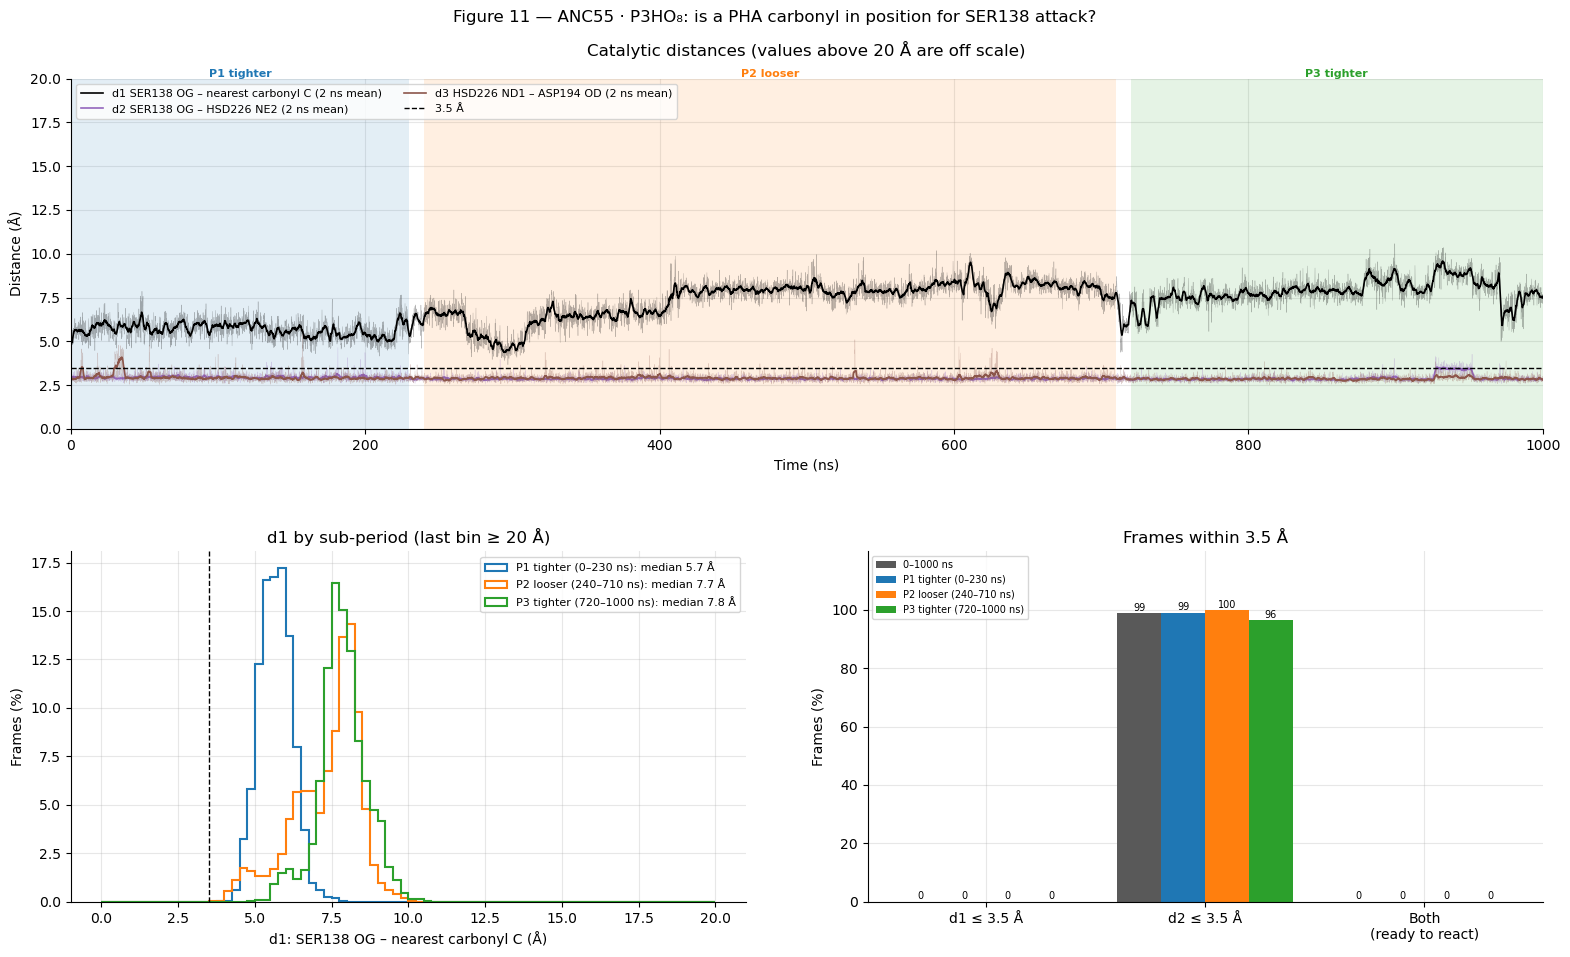

,frames,d1_within_percent,d2_within_percent,ready_percent,d3_within_percent,d1_median_A,d2_median_A,d3_median_A
label,,,,,,,,
0–1000 ns,10001,0.0,98.70,0.0,98.54,7.38,2.86,2.87
P1 tighter (0–230 ns),2301,0.0,98.96,0.0,96.18,5.68,2.92,2.88
P2 looser (240–710 ns),4701,0.0,99.94,0.0,98.94,7.67,2.84,2.88
P3 tighter (720–1000 ns),2801,0.0,96.32,0.0,99.82,7.84,2.84,2.84


Nearest carbonyl to SER138 OG, % of frames by unit (1 = hydroxyl end, 8 = acid end):


,all,P1,P2,P3
unit,,,,
1,42.9,0.0,50.1,65.7
2,6.5,0.1,12.3,2.6
3,36.1,89.0,26.8,7.3
4,10.8,10.9,6.4,18.7
5,2.1,0.0,1.9,4.5
6,0.9,0.0,1.7,0.6
7,0.6,0.0,0.9,0.5
8,0.0,0.0,0.0,0.1


In [8]:
from MDAnalysis.lib.distances import distance_array

og, ne2, nd1 = ATOMS['SER138_OG'], ATOMS['HSD226_NE2'], ATOMS['HSD226_ND1']
od = ATOMS['ASP194_OD1'] + ATOMS['ASP194_OD2']
d1 = np.empty(len(T)); d2 = np.empty(len(T)); d3 = np.empty(len(T)); nearest = []
for i, ts in enumerate(U.trajectory[int(FRAMES[0]):int(FRAMES[-1]) + 1]):
    if not np.isclose(ts.time / 1000, T[i], atol=1e-6): raise ValueError('Frame/time mismatch')
    box = ts.dimensions
    dc = distance_array(og.positions, CARBONYL_C.positions, box=box)[0]
    j = int(np.argmin(dc)); d1[i] = dc[j]; nearest.append(CARBONYL_C[j].name)
    d2[i] = distance_array(og.positions, ne2.positions, box=box)[0, 0]
    d3[i] = distance_array(nd1.positions, od.positions, box=box).min()
U.trajectory[0]
geo = pd.DataFrame({'frame': FRAMES, 'time_ns': T, 'period': period_of, 'd1_SerOG_carbonylC_A': d1, 'nearest_carbonyl': nearest,
                    'nearest_carbonyl_unit': [CARBONYL_UNIT[n] for n in nearest],
                    'nearest_carbonyl_kind': [CARBONYL_KIND[n] for n in nearest],
                    'd2_SerOG_HisNE2_A': d2, 'd3_HisND1_AspOD_A': d3})
geo['ready_to_react'] = (geo.d1_SerOG_carbonylC_A <= READY_CUTOFF_A) & (geo.d2_SerOG_HisNE2_A <= READY_CUTOFF_A)
masks = group_masks(T)
ready_table = pd.DataFrame([{'group': g, 'label': GROUP_LABEL[g], 'frames': int(m.sum()),
                             'd1_within_percent': 100 * (d1[m] <= READY_CUTOFF_A).mean(),
                             'd2_within_percent': 100 * (d2[m] <= READY_CUTOFF_A).mean(),
                             'ready_percent': 100 * geo.ready_to_react.to_numpy()[m].mean(),
                             'd3_within_percent': 100 * (d3[m] <= READY_CUTOFF_A).mean(),
                             'd1_median_A': np.median(d1[m]), 'd2_median_A': np.median(d2[m]), 'd3_median_A': np.median(d3[m])}
                            for g, m in masks.items()])
nearest_table = pd.concat([geo.loc[m, 'nearest_carbonyl_unit'].value_counts(normalize=True).mul(100).rename(g) for g, m in masks.items()],
                          axis=1).fillna(0.0).sort_index()
nearest_table.index.name = 'unit'

fig = plt.figure(figsize=(2 * FIGSIZE[0], 2 * FIGSIZE[1] + 0.8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.35, wspace=0.18)
ax = fig.add_subplot(gs[0, :]); shade_periods(ax, label=True)
for v, colour, name in [(d1, 'k', 'd1 SER138 OG – nearest carbonyl C'), (d2, 'tab:purple', 'd2 SER138 OG – HSD226 NE2'),
                        (d3, 'tab:brown', 'd3 HSD226 ND1 – ASP194 OD')]:
    ax.plot(T, v, color=colour, lw=0.3, alpha=0.3)
    ax.plot(T, roll(v), color=colour, lw=1.2, label=f'{name} ({SMOOTH_NS:g} ns mean)')
ax.axhline(READY_CUTOFF_A, color='k', ls='--', lw=1, label=f'{READY_CUTOFF_A:g} Å')
ax.set(ylabel='Distance (Å)', xlabel='Time (ns)', ylim=(0, 20), xlim=FULL_RANGE)
ax.set_title('Catalytic distances (values above 20 Å are off scale)', pad=16)
ax.legend(loc='upper left', fontsize=8, ncol=2); tidy(ax)
ax = fig.add_subplot(gs[1, 0])
bins = np.arange(0, 20.25, 0.25)
for p in PERIODS:
    v = np.clip(d1[masks[p]], 0, bins[-1] - 1e-9)
    ax.hist(v, bins=bins, weights=np.full(len(v), 100 / len(v)), histtype='step', lw=1.5, color=COLOURS[p],
            label=f'{GROUP_LABEL[p]}: median {np.median(d1[masks[p]]):.1f} Å')
ax.axvline(READY_CUTOFF_A, color='k', ls='--', lw=1)
ax.set(xlabel='d1: SER138 OG – nearest carbonyl C (Å)', ylabel='Frames (%)', title='d1 by sub-period (last bin ≥ 20 Å)')
ax.legend(fontsize=8); tidy(ax)
ax = fig.add_subplot(gs[1, 1])
cats = [('d1_within_percent', 'd1 ≤ 3.5 Å'), ('d2_within_percent', 'd2 ≤ 3.5 Å'), ('ready_percent', 'Both\n(ready to react)')]
vals = {g: ready_table.set_index('group').loc[g, [c for c, _ in cats]].to_numpy(float) for g in GROUPS}
pos = group_bars(ax, [n for _, n in cats], vals)
wbar = 0.8 / len(GROUPS)
for j, g in enumerate(GROUPS):
    for x, v in zip(pos + (j - (len(GROUPS) - 1) / 2) * wbar, vals[g]): ax.text(x, v + 0.8, f'{v:.0f}', ha='center', fontsize=7)
ax.set(xticks=pos, xticklabels=[n for _, n in cats], ylabel='Frames (%)', ylim=(0, max(10, max(max(v) for v in vals.values()) * 1.2)),
       title=f'Frames within {READY_CUTOFF_A:g} Å')
ax.legend(fontsize=7, loc='upper left'); tidy(ax)
fig.suptitle('Figure 11 — ANC55 · P3HO₈: is a PHA carbonyl in position for SER138 attack?')
fig.subplots_adjust(top=0.91, bottom=0.07, left=0.06, right=0.98)
save_png(fig, 'fig11_catalytic_geometry.png')
display(fig); plt.close(fig)
save_csv(geo, 'fig11_catalytic_distances.csv')
save_csv(ready_table, 'fig11_ready_to_react.csv')
save_csv(nearest_table.reset_index(), 'fig11_nearest_carbonyl_unit.csv')
display(ready_table.drop(columns='group').set_index('label').round(2))
print('Nearest carbonyl to SER138 OG, % of frames by unit (1 = hydroxyl end, 8 = acid end):')
display(nearest_table.round(1))

### Figure 12 — Which part of the P3HO₈ chain binds

**Question:** does the chain end or the middle of the PHA sit at the catalytic SER138? The chain is split into its 8 repeat units at the 7 ester bonds, numbered from the hydroxyl end (unit 1) to the acid end (unit 8); each unit is –O–CH(C₅H₁₁)–CH₂–C(=O)–. Per frame (every 0.1 ns, PBC-aware), a unit is in contact when any of its heavy atoms is within 3.5 Å of a heavy atom of any protein residue, of SER48 or of SER138. **How to read it:** each panel shows, per unit, the % of frames in contact for 0–1000 ns and each sub-period.

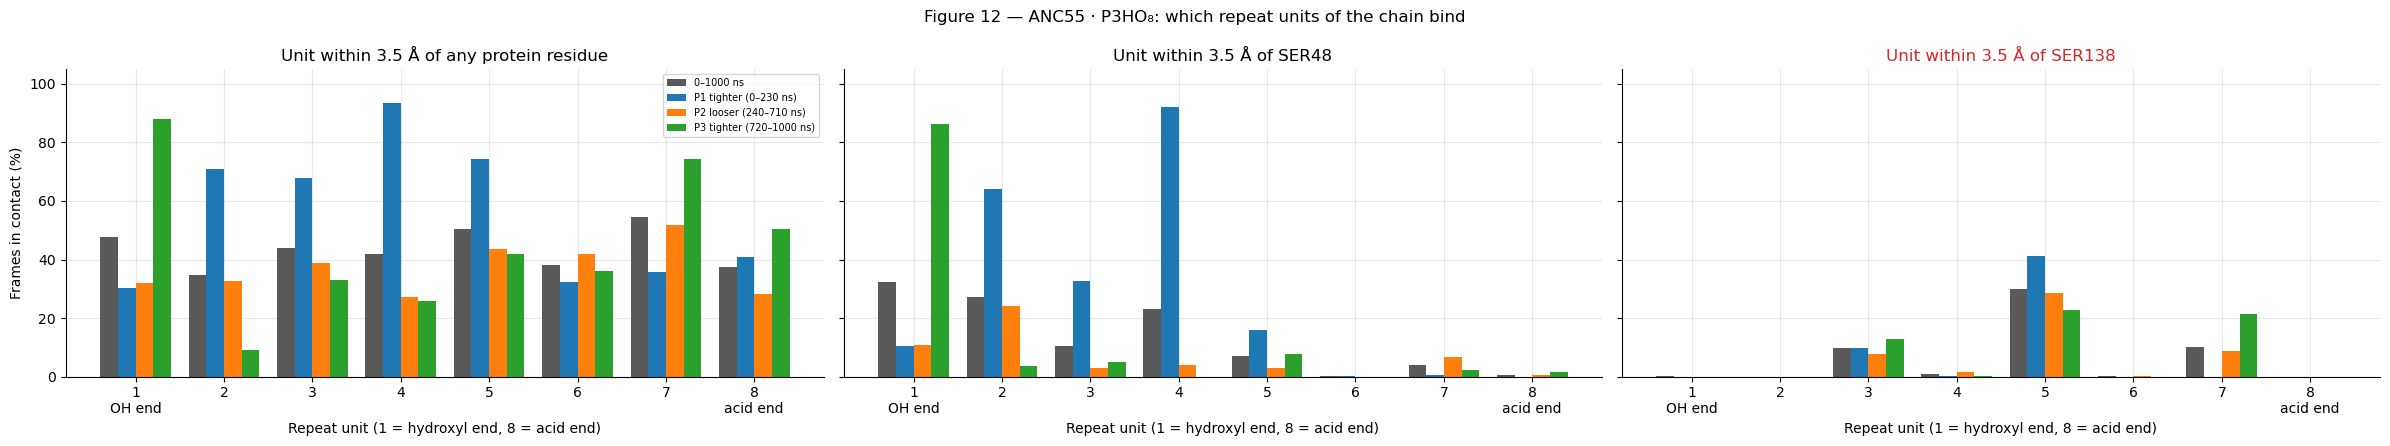

label                     0–1000 ns  P1 tighter (0–230 ns)  \
target              unit                                     
SER138              1           0.0                    0.0   
                    2           0.0                    0.0   
                    3           9.7                    9.9   
                    4           0.9                    0.2   
                    5          30.1                   41.1   
                    6           0.1                    0.0   
                    7          10.1                    0.0   
                    8           0.0                    0.0   
SER48               1          32.4                   10.4   
                    2          27.3                   64.2   
                    3          10.3                   32.7   
                    4          23.0                   92.0   
                    5           7.1                   15.8   
                    6           0.1                    0.3   
                    7           4.0                    0.5   
                    8           0.6                    0.0   
any protein residue 1          47.6                   30.3   
                    2          34.6                   70.8   
                    3          43.9                   67.7   
                    4          41.9                   93.4   
                    5          50.5                   74.4   
                    6          38.3                   32.2   
                    7          54.4                   35.7   
                    8          37.3                   40.9   

label                     P2 looser (240–710 ns)  P3 tighter (720–1000 ns)  
target              unit                                                    
SER138              1                        0.0                       0.0  
                    2                        0.0                       0.0  
                    3                        7.8                      12.9  
                    4                        1.7                       0.2  
                    5                       28.5                      22.7  
                    6                        0.3                       0.0  
                    7                        8.7                      21.5  
                    8                        0.0                       0.0  
SER48               1                       10.9                      86.2  
                    2                       24.2                       3.7  
                    3                        2.9                       5.0  
                    4                        4.0                       0.0  
                    5                        2.7                       7.6  
                    6                        0.0                       0.0  
                    7                        6.7                       2.2  
                    8                        0.4                       1.5  
any protein residue 1                       32.0                      88.1  
                    2                       32.6                       9.1  
                    3                       38.8                      33.1  
                    4                       27.2                      25.8  
                    5                       43.7                      41.8  
                    6                       41.9                      36.1  
                    7                       51.8                      74.3  
                    8                       28.2                      50.4

In [9]:
prot_heavy = PROTEIN[PROTEIN.masses > 3]
unit_heavy = [u[u.masses > 3] for u in UNITS]
lig_heavy = sum(unit_heavy[1:], unit_heavy[0])
starts = np.cumsum([0] + [len(u) for u in unit_heavy[:-1]])
cols48 = np.flatnonzero((prot_heavy.resids == 48) & (prot_heavy.resnames == 'SER'))
cols138 = np.flatnonzero((prot_heavy.resids == 138) & (prot_heavy.resnames == 'SER'))
n_units = len(UNITS)
dmin_any = np.empty((len(T), n_units)); dmin_48 = np.empty((len(T), n_units)); dmin_138 = np.empty((len(T), n_units))
for i, ts in enumerate(U.trajectory[int(FRAMES[0]):int(FRAMES[-1]) + 1]):
    if not np.isclose(ts.time / 1000, T[i], atol=1e-6): raise ValueError('Frame/time mismatch')
    dd = distance_array(lig_heavy.positions, prot_heavy.positions, box=ts.dimensions)
    dmin_any[i] = np.minimum.reduceat(dd.min(axis=1), starts)
    dmin_48[i] = np.minimum.reduceat(dd[:, cols48].min(axis=1), starts)
    dmin_138[i] = np.minimum.reduceat(dd[:, cols138].min(axis=1), starts)
U.trajectory[0]
# Checks: the unit minima reproduce the saved global and residue distances.
col = {r: residues.distance_column[(residues.resname == r[0]) & (residues.resid == r[1])].iloc[0] for r in [('SER', 48), ('SER', 138)]}
for name, got, ref in [('global minimum', dmin_any.min(axis=1), GMIN), ('SER48', dmin_48.min(axis=1), distances[col[('SER', 48)]].to_numpy()),
                       ('SER138', dmin_138.min(axis=1), distances[col[('SER', 138)]].to_numpy())]:
    if not np.allclose(got, ref, atol=1e-4):
        raise ValueError(f'Unit distances do not reproduce the saved {name} distances (max error {np.abs(got - ref).max():.2e} Å)')

masks = group_masks(T)
unit_rows = []
for target, dm in [('any protein residue', dmin_any), ('SER48', dmin_48), ('SER138', dmin_138)]:
    for g, m in masks.items():
        pct = 100 * (dm[m] <= CONTACT_CUTOFF_A).mean(axis=0)
        unit_rows += [{'target': target, 'group': g, 'label': GROUP_LABEL[g], 'unit': k + 1, 'contact_percent': pct[k]} for k in range(n_units)]
units12 = pd.DataFrame(unit_rows)
unit_names = [f'{k}\n' + ('OH end' if k == 1 else 'acid end' if k == n_units else '') for k in range(1, n_units + 1)]

fig, axes = plt.subplots(1, 3, figsize=(3 * FIGSIZE[0], FIGSIZE[1]), sharey=True)
for ax, target in zip(axes, ['any protein residue', 'SER48', 'SER138']):
    sub = units12.loc[units12.target == target]
    pos = group_bars(ax, unit_names, {g: sub.loc[sub.group == g].sort_values('unit').contact_percent.to_numpy() for g in GROUPS})
    ax.set(xticks=pos, xticklabels=unit_names, xlabel='Repeat unit (1 = hydroxyl end, 8 = acid end)', ylim=(0, 105),
           title=f'Unit within {CONTACT_CUTOFF_A:g} Å of {target}')
    if target == 'SER138': ax.title.set_color(TRIAD_COLOUR)
    tidy(ax)
axes[0].set_ylabel('Frames in contact (%)'); axes[0].legend(fontsize=7, loc='upper right')
fig.suptitle('Figure 12 — ANC55 · P3HO₈: which repeat units of the chain bind')
fig.tight_layout()
save_png(fig, 'fig12_repeat_unit_contacts.png')
display(fig); plt.close(fig)
per_frame12 = pd.DataFrame({'frame': FRAMES, 'time_ns': T, 'period': period_of})
for name, dm in [('any', dmin_any), ('SER48', dmin_48), ('SER138', dmin_138)]:
    for k in range(n_units): per_frame12[f'unit{k + 1}_min_distance_{name}_A'] = dm[:, k]
save_csv(per_frame12, 'fig12_unit_min_distances.csv')
save_csv(units12, 'fig12_unit_contact_percent.csv')
display(units12.pivot_table(index=['target', 'unit'], columns='label', values='contact_percent').round(1))

### Summary

The table collects the key numbers from Figures 7–12 for 0–1000 ns and for each sub-period; it is generated from this run and saved as `summary.csv`.

In [10]:
def by_group(fn): return {GROUP_LABEL[g]: fn(g) for g in GROUPS}
def top_res(g, n=3):
    c = 'occupancy_3p5A_0_1000ns' if g == 'all' else f'occupancy_3p5A_{g}'
    return ', '.join(f'{r.resname}{r.resid} {r[c]:.0f}' for _, r in occ.nlargest(n, c).iterrows())
def triad(g):
    c = 'occupancy_3p5A_0_1000ns' if g == 'all' else f'occupancy_3p5A_{g}'
    return ', '.join(f'{r.resname}{r.resid} {r[c]:.0f}' for _, r in occ.iloc[TRIAD_IDX].iterrows())
def s10(g, v):
    r = stats10.loc[(stats10.group == g) & (stats10.variable == v)].iloc[0]; return f"{r['mean']:.1f} ± {r['sd']:.1f}"
def s9(g, comp):
    r = stats9.loc[(stats9.group == g) & (stats9.component == comp)].iloc[0]; return f"{r.mean_kj_mol:.0f} ± {r.block_sd_kj_mol:.0f}"
def top_unit(g, target):
    sub = units12.loc[(units12.target == target) & (units12.group == g)].sort_values('contact_percent', ascending=False).head(2)
    return ', '.join(f'unit {int(r.unit)} {r.contact_percent:.0f}' for _, r in sub.iterrows())
rt = ready_table.set_index('group'); f10 = focus10.set_index('group'); s7 = stats7.set_index('group')
summary = pd.DataFrame({
    'Median minimum distance (Å)': by_group(lambda g: f"{f10.loc[g, 'median_min_distance_A']:.2f}"),
    'Leading residues, ≤3.5 Å (% time)': by_group(top_res),
    'Active site, ≤3.5 Å (% time)': by_group(triad),
    'Residues ≤3.5 Å per frame': by_group(lambda g: s10(g, 'residues_within_3p5A')),
    'Residues ≤4.5 Å per frame': by_group(lambda g: s10(g, 'residues_within_4p5A')),
    'H-bonds per frame': by_group(lambda g: s10(g, 'hbonds')),
    f'{focus} H-bond (% frames)': by_group(lambda g: f"{f10.loc[g, f'frames_with_{focus}_hbond_percent']:.0f}"),
    'Top H-bond partner (% frames)': by_group(lambda g: f"{partners[g].idxmax()} ({partners[g].max():.0f})"),
    'Interaction energy Coulomb + LJ (kJ/mol, ± 10 ns block SD)': by_group(lambda g: s9(g, 'Coulomb + LJ')),
    'of which Coulomb / LJ (kJ/mol)': by_group(lambda g: f"{s9(g, 'Coulomb').split(' ')[0]} / {s9(g, 'Lennard-Jones').split(' ')[0]}"),
    'd1 SER138 OG – carbonyl C ≤3.5 Å (% frames)': by_group(lambda g: f"{rt.loc[g, 'd1_within_percent']:.1f}"),
    'd2 SER138 OG – HSD226 NE2 ≤3.5 Å (% frames)': by_group(lambda g: f"{rt.loc[g, 'd2_within_percent']:.1f}"),
    'Both, ready to react (% frames)': by_group(lambda g: f"{rt.loc[g, 'ready_percent']:.1f}"),
    'Nearest carbonyl to SER138 OG (unit, % frames)': by_group(lambda g: f"unit {nearest_table[g].idxmax()} ({nearest_table[g].max():.0f})"),
    'Units touching SER138 (% frames)': by_group(lambda g: top_unit(g, 'SER138')),
    'Units touching SER48 (% frames)': by_group(lambda g: top_unit(g, 'SER48')),
}).T
summary.index.name = 'metric'
save_csv(summary.reset_index(), 'summary.csv')
display(summary)
print(f'Figure 7: 50 ns contact-profile similarity min {SIM_MIN:.2f}, median {SIM_MEDIAN:.2f}.')

,0–1000 ns,P1 tighter (0–230 ns),P2 looser (240–710 ns),P3 tighter (720–1000 ns)
metric,,,,
Median minimum distance (Å),2.91,2.73,3.21,2.75
"Leading residues, ≤3.5 Å (% time)","SER48 68, SER138 45, GLN93 29","SER48 98, SER138 46, ASN95 44","SER48 42, SER138 41, ILE196 25","SER48 89, GLN93 55, SER138 50"
"Active site, ≤3.5 Å (% time)","SER138 45, ASP194 0, HSD226 13","SER138 46, ASP194 0, HSD226 26","SER138 41, ASP194 0, HSD226 10","SER138 50, ASP194 0, HSD226 8"
Residues ≤3.5 Å per frame,3.9 ± 1.8,4.5 ± 1.8,3.5 ± 1.7,4.2 ± 1.6
Residues ≤4.5 Å per frame,18.0 ± 2.7,18.7 ± 2.8,17.0 ± 2.5,19.2 ± 2.2
H-bonds per frame,0.6 ± 0.7,1.0 ± 0.6,0.2 ± 0.4,0.9 ± 0.8
SER48 H-bond (% frames),37,75,4,63
Top H-bond partner (% frames),"SER48 · PHA O8 (C=O, unit 4) (19)","SER48 · PHA O8 (C=O, unit 4) (75)","GLN93 · PHA O17 (OH, unit 8) (3)","SER48 · PHA O2 (C=O, unit 1) (42)"
"Interaction energy Coulomb + LJ (kJ/mol, ± 10 ns block SD)",-229 ± 41,-274 ± 30,-197 ± 26,-246 ± 21


Figure 7: 50 ns contact-profile similarity min 0.65, median 0.81.


### In plain language

ANC55 holds P3HO₈ at a single site for the whole microsecond: the PHA is within 3.5 Å of the enzyme in about 99 % of frames, the same residues (SER48, SER138, GLN93, ILE196, PHE62, LEU169) lead throughout, and every pair of 50 ns contact profiles is similar (cosine similarity at least 0.65, median 0.81). The tighter sub-periods P1 and P3 coincide with a hydrogen bond from SER48 to the PHA (75 % and 63 % of frames, against 4 % in P2): with it the minimum distance is about 2.7 Å and without it about 3.2 Å, and the short-range interaction energy is stronger (−274 ± 30 and −246 ± 21 kJ/mol, against −197 ± 26 kJ/mol in P2) — though SER48 holds the unit-4 carbonyl in P1 but the hydroxyl-end unit 1 in P3. The middle of the chain, not an end, sits at the catalytic SER138: units 3, 5 and 7 touch it (unit 5 in 30 % of frames), while the end units 1 and 8 never do. Even so, no PHA carbonyl carbon comes within 3.5 Å of SER138 OG (closest 3.7 Å, median 7.4 Å) although the Ser–His–Asp triad stays intact (SER138 OG – HSD226 NE2 within 3.5 Å in 99 % of frames), so this run shows a stable pre-catalytic binding site rather than a pose ready for ester cleavage.

*Written from run outputs with the settings above; the table in the cell before is regenerated on every run.*

### Provenance and limitations

This cell writes `provenance.json` (input fingerprints, settings, software versions and the list of saved files) and closes the trajectory.

In [11]:
import sys, MDAnalysis
U.trajectory.close(); shutil.rmtree(SCRATCH, ignore_errors=True)
inputs = {k: file_record(p, digest=k not in ('xtc', 'edr')) for k, p in PATHS.items()}   # XTC/EDR: size and mtime, checked against saved provenance
if {k: file_record(PATHS[k]) for k in ('tpr', 'xtc')} != {k: {kk: inputs[k][kk] for kk in ('path', 'size', 'mtime_ns')} for k in ('tpr', 'xtc')}:
    raise RuntimeError('Inputs changed during the run')
provenance = {
    'notebook': 'src/md_simulation_scripts/enzyme_pha_analysis/ANC55_P3HO8_binding_site.ipynb',
    'run_tag': RUN_TAG, 'created': datetime.now().isoformat(timespec='seconds'), 'output_dir': str(OUTPUT_DIR),
    'inputs': inputs,
    'settings': {'periods_ns': PERIODS, 'period_kind': PERIOD_KIND, 'contact_cutoff_A': CONTACT_CUTOFF_A, 'close_cutoff_A': CLOSE_CUTOFF_A,
                 'active_site': {k: f'{r}{i}' for k, (r, i, _) in ACTIVE_SITE.items()}, 'smooth_ns': SMOOTH_NS,
                 'heatmap_bin_ns': HEATMAP_BIN_NS, 'profile_bin_ns': PROFILE_BIN_NS, 'leading_percent': LEADING_PERCENT,
                 'top_n_residues': TOP_N_RESIDUES, 'reference_occupancy': {f'{r}{i}': v for (r, i), v in REFERENCE_OCCUPANCY.items()},
                 'rerun_step_ns': RERUN_STEP_NS, 'block_ns': BLOCK_NS, 'hbond_step_ns': HBOND_STEP_NS,
                 'hbond_da_cutoff_A': HBOND_DA_CUTOFF_A, 'hbond_angle_deg': HBOND_ANGLE_DEG, 'ready_cutoff_A': READY_CUTOFF_A,
                 'carbonyl_carbons': CARBONYL_KIND, 'carbonyl_unit': CARBONYL_UNIT, 'pha_hbond_donors': LIG_DONORS,
                 'units': UNIT_TABLE.to_dict('records'), 'similarity_50ns_min': SIM_MIN, 'similarity_50ns_median': SIM_MEDIAN,
                 'run_rerun': RUN_RERUN, 'rerun_dir': str(RERUN_DIR), 'rerun_energy_csv_sha256': sha256(ENERGY_FILE),
                 'rerun_potential_median_rel_diff_percent': float(pot_rel.median())},
    'software': {'python': sys.version.split()[0], 'platform': platform.platform(), 'numpy': np.__version__,
                 'pandas': pd.__version__, 'matplotlib': matplotlib.__version__, 'MDAnalysis': MDAnalysis.__version__},
    'outputs': {p.name: sha256(p) for p in SAVED},
}
path = OUTPUT_DIR / 'provenance.json'
if path.exists(): raise FileExistsError(path)
path.write_text(json.dumps(provenance, indent=2, default=str))
display(Markdown(f'''
**Inputs.** `{PATHS['tpr'].name}`, `{PATHS['xtc'].name}` (0–1000 ns, {DT:g} ns frames), `{PATHS['edr'].name}` (Figure 9 check only)
and the saved CSVs with prefix `{SOURCE_PREFIX}`. TPR/XTC size and modification time match the saved provenance, the CSV
SHA-256 hashes match the residue-analysis metadata, and the saved contacts, occupancies and top-10 table are reproduced.
All fingerprints are in `provenance.json`; {len(SAVED)} files were saved to `{OUTPUT_DIR}`.

**Limitations.**
- One trajectory of one system. All numbers describe this run only; there are no replicas, so no significance is implied.
- P1–P3 were chosen by eye from steps in the minimum-distance trace of this same trajectory (gaps 230–240 and
  710–720 ns are left out of the per-period numbers). They are sub-periods of one site, not separate states.
- Residue occupancies are time-weighted with interpolated cutoff crossings; unit contacts (Figure 12), catalytic
  distances (Figure 11) and H-bonds (Figure 10, every {HBOND_STEP_NS:g} ns) are simple fractions of frames.
- Contacts use minimum heavy-atom distances; hydrogen bonds use geometric criteria only (no energies). PHA donors are
  the two O–H groups ({', '.join(LIG_DONORS)}).
- Figure 9 is the short-range PROT–LIG interaction energy from a rerun of one frame every {RERUN_STEP_NS:g} ns of the XTC
  (coordinates rounded to 0.001 nm; the rerun Potential is within a median {pot_rel.median():.2f} % of the production
  energies). Long-range PME and entropy are missing, so it is not a binding free energy; block SDs assume 10 ns blocks
  are roughly independent.
- "Ready to react" is a distance criterion (d1, d2 ≤ {READY_CUTOFF_A:g} Å). It ignores the attack angle, the oxyanion hole,
  protonation changes and reaction energetics. Of the eight CG2O2 carbons, seven are ester carbonyls and one
  ({', '.join(n for n, k in CARBONYL_KIND.items() if k != 'ester')}) is the acid end; d1 uses all eight.
'''))


**Inputs.** `step7_production.tpr`, `processed_protein_centered.xtc` (0–1000 ns, 0.1 ns frames), `production_combined_1us.edr` (Figure 9 check only)
and the saved CSVs with prefix `ANC55_P3HO8_new_enzyme_20261008_0_1000ns_v1`. TPR/XTC size and modification time match the saved provenance, the CSV
SHA-256 hashes match the residue-analysis metadata, and the saved contacts, occupancies and top-10 table are reproduced.
All fingerprints are in `provenance.json`; 27 files were saved to `/Users/k20098771/Data/MD_projects/PHA/MD_data/gromacs/PHA_new_Enzyme/ANC55_P3HO8_gromacs/analysis/binding_site_ANC55_P3HO8/20261008_203845`.

**Limitations.**
- One trajectory of one system. All numbers describe this run only; there are no replicas, so no significance is implied.
- P1–P3 were chosen by eye from steps in the minimum-distance trace of this same trajectory (gaps 230–240 and
  710–720 ns are left out of the per-period numbers). They are sub-periods of one site, not separate states.
- Residue occupancies are time-weighted with interpolated cutoff crossings; unit contacts (Figure 12), catalytic
  distances (Figure 11) and H-bonds (Figure 10, every 0.5 ns) are simple fractions of frames.
- Contacts use minimum heavy-atom distances; hydrogen bonds use geometric criteria only (no energies). PHA donors are
  the two O–H groups (O1–H1, O17–H114).
- Figure 9 is the short-range PROT–LIG interaction energy from a rerun of one frame every 1 ns of the XTC
  (coordinates rounded to 0.001 nm; the rerun Potential is within a median 0.10 % of the production
  energies). Long-range PME and entropy are missing, so it is not a binding free energy; block SDs assume 10 ns blocks
  are roughly independent.
- "Ready to react" is a distance criterion (d1, d2 ≤ 3.5 Å). It ignores the attack angle, the oxyanion hole,
  protonation changes and reaction energetics. Of the eight CG2O2 carbons, seven are ester carbonyls and one
  (C64) is the acid end; d1 uses all eight.
